# Thesis Publication Figures

This notebook prepares publication-style figures for the multihole Mie pipeline and the Stage-1 MLP section.

Generated thesis-body figures in this version. Each `.png` is also exported with a `.pdf` sibling for LaTeX vector text:

- `images/fig_gui_calibration_workflow.png`
- `images/fig_mie_preproc_background.png`
- `images/fig_mie_preproc_sobel.png`
- `images/fig_threshold_mask_repair_summary.png`
- `images/fig_angular_occupancy.png`
- `images/fig_efficient_rotation.png`
- `images/fig_mie_metrics_summary.png`
- `images/fig_round1_median_selection.png`
- `images/fig_round1_loss.png`

Legacy/debug figures still available for appendix or troubleshooting:

- `images/fig_mie_highpass_histogram.png`
- `images/fig_mie_highpass_bw_frame_compare.png`
- `images/fig_mie_bw_repair_demo.png`
- `images/fig_angular_mask_comparison.png`

Deferred/manual figures:

- `fig_round2_uncertainty_placeholder` (deferred)
- `fig_round3_refinement_placeholder` (deferred)


## Source Anchors

This notebook is anchored to the following dataset:

- cine: `F:\\LubeOil\\BC20241014_HZ_Nozzle3\\Cine\\T4\\T4(2).cine`
- config: `F:\\LubeOil\\BC20241014_HZ_Nozzle3\\Cine\\T4\\config.json`

Pipeline references reused conceptually or directly:

- `main.py`
- `mie_multihole_pipeline.py`
- `OSCC_postprocessing/binary_ops/masking.py`
- `OSCC_postprocessing/analysis/cone_angle.py`
- `OSCC_postprocessing/analysis/multihole_utils.py`
- `OSCC_postprocessing/rotation/rotate_with_alignment_cpu.py`
- `MLP/median_penetration_MSE.ipynb`


## 00 Setup


In [1]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import Arc, Circle


def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import mie_multi_hole as mmh
IMAGE_DIR = PROJECT_ROOT / "images"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
VIDEO_DIR = IMAGE_DIR / "avi"
VIDEO_DIR.mkdir(parents=True, exist_ok=True)


plt.rcParams.update(
    {
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "font.family": "DejaVu Serif",
        "axes.titlesize": 9,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }
)

COLORS = {
    "ink": "#16213e",
    "accent": "#0f766e",
    "warm": "#c2410c",
    "gold": "#b45309",
    "red": "#d01414",
    "blue": "#1d4ed8",
    "gray": "#6b7280",
}


In [57]:
# =============================================================================
# File Selections
# =============================================================================

CINE_PATH = Path(r"F:\LubeOil\BC20220627 - Heinzman DS300 - Mie Top view\Cine\T9\75.cine")


CONFIG_PATH = Path(r"F:\LubeOil\BC20220627 - Heinzman DS300 - Mie Top view\Cine\T9\config.json")

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"IMAGE_DIR     = {IMAGE_DIR}")
print(f"VIDEO_DIR     = {VIDEO_DIR}")
print(f"CINE_PATH     = {CINE_PATH}")
print(f"CONFIG_PATH   = {CONFIG_PATH}")


PROJECT_ROOT = C:\Users\Jiang\Documents\Mie_Postprocessing_Py
IMAGE_DIR     = C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images
VIDEO_DIR     = C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\avi
CINE_PATH     = F:\LubeOil\BC20220627 - Heinzman DS300 - Mie Top view\Cine\T9\75.cine
CONFIG_PATH   = F:\LubeOil\BC20220627 - Heinzman DS300 - Mie Top view\Cine\T9\config.json


In [ ]:
# =============================================================================
# Image processing config (mirrors main.py)
# =============================================================================

frame_limit = 100
frames_before_soi = 20
noise_floor_multiplier = 4

# Pre-processing histogram scaling and edge-energy settings
sobel_wsize = 3
sobel_sigma = 1
threshold = 0.02
q_min_foreground = 5
q_max_foreground = 99.99
q_min_highpass = 5
q_max_highpass = 99.9999

# Angular occupancy / rotation settings
angular_bins = 720
interpolation_mode = "nearest"
border_mode = "constant"
upper_quantile_cdf = 1 - 5e-3
angular_occupancy_max_gap = 3
q_min_angular_profile = 2
q_max_angular_profile = 99.8


# Binary plume support settings
segment_bw_q_min = 5
segment_bw_q_max = 90
global_bw_threshold = 0.01
repair_bw_for_figures = False
penetration_cleanup_min_len = 5

# BW feature extraction settings
nozzle_opening_detection_height = 20
nozzle_opening_detection_width = 30
thres_penetration_num_pix = 5
save_boundary_points_csv = False

# =============================================================================
# Default nozzle properties, safe fallback if not defined in test matrix or cine
# =============================================================================

FPS_default = 34000
injection_pressure_bar_default = 2000
control_backpressure_bar_default = 4
umbrella_angle_deg_default = 180

# =============================================================================
representative_frame_idx_input = 30                # Frame index for viewing, change to after SOI to see effects on multiple scattering
representative_frame_strategy = "peak_highpass_energy"


## 01 Dataset Anchor


In [59]:
with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CONFIG = json.load(f)

MIE_GEOMETRY = {
    "plumes": int(CONFIG["plumes"]),
    "offset": float(CONFIG["offset"]),
    "centre": (float(CONFIG["centre_x"]), float(CONFIG["centre_y"])),
    "inner_radius": float(CONFIG["inner_radius"]),
    "outer_radius": float(CONFIG["outer_radius"]),
}

print(json.dumps(MIE_GEOMETRY, indent=2))


{
  "plumes": 10,
  "offset": 36.11,
  "centre": [
    383.205,
    385.19
  ],
  "inner_radius": 13.0,
  "outer_radius": 412.0
}


## 02 Shared Helpers


In [60]:
OPTIONAL_IMPORTS: dict[str, str] = {}


def optional_import(name: str):
    try:
        module = __import__(name, fromlist=["*"])
        OPTIONAL_IMPORTS[name] = "OK"
        return module
    except Exception as exc:
        OPTIONAL_IMPORTS[name] = f"FAILED: {type(exc).__name__}: {exc}"
        return None


repo_masking = optional_import("OSCC_postprocessing.binary_ops.masking")
repo_cone = optional_import("OSCC_postprocessing.analysis.cone_angle")
repo_multi = optional_import("OSCC_postprocessing.analysis.multihole_utils")
repo_rotate = optional_import("OSCC_postprocessing.rotation.rotate_with_alignment_cpu")
repo_hysteresis = optional_import("OSCC_postprocessing.analysis.hysteresis")
repo_cine = optional_import("OSCC_postprocessing.cine.functions_videos")
repo_features = optional_import("OSCC_postprocessing.binary_ops.feature_extraction")
repo_playback = optional_import("OSCC_postprocessing.playback.video_playback")
repo_avi = optional_import("OSCC_postprocessing.io.async_avi_saver")
repo_main = optional_import("main")

OPTIONAL_IMPORTS


{'OSCC_postprocessing.binary_ops.masking': 'OK',
 'OSCC_postprocessing.analysis.cone_angle': 'OK',
 'OSCC_postprocessing.analysis.multihole_utils': 'OK',
 'OSCC_postprocessing.rotation.rotate_with_alignment_cpu': 'OK',
 'OSCC_postprocessing.analysis.hysteresis': 'OK',
 'OSCC_postprocessing.cine.functions_videos': 'OK',
 'OSCC_postprocessing.binary_ops.feature_extraction': 'OK',
 'OSCC_postprocessing.playback.video_playback': 'OK',
 'OSCC_postprocessing.io.async_avi_saver': 'OK',
 'main': "FAILED: ModuleNotFoundError: No module named 'main'"}

In [61]:
def add_panel_labels(axs, labels=None, x=0.01, y=0.99):
    labels = labels or list("abcdefghijklmnopqrstuvwxyz")
    for ax, label in zip(np.ravel(axs), labels):
        ax.text(
            x,
            y,
            f"({label})",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            fontweight="bold",
            color=COLORS["ink"],
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 1.5},
        )


def export_figure(fig, filename: str, show_inline: bool = True, save_pdf: bool = True):
    out_path = IMAGE_DIR / filename
    fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    saved_paths = [out_path]
    if save_pdf and out_path.suffix.lower() != ".pdf":
        pdf_path = out_path.with_suffix(".pdf")
        fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
        saved_paths.append(pdf_path)
    if show_inline:
        display(fig)
    print("Saved " + ", ".join(str(path) for path in saved_paths))
    return out_path


def to_numpy(arr):
    if hasattr(arr, "get"):
        arr = arr.get()
    elif hasattr(arr, "__cuda_array_interface__"):
        try:
            import cupy as cp
            arr = cp.asnumpy(arr)
        except Exception:
            pass
    return np.asarray(arr)


def robust_scale_local(arr, q_min=5.0, q_max=99.5, clip=True, eps=1e-8):
    arr = to_numpy(arr).astype(float, copy=False)
    lo = np.nanpercentile(arr, q_min)
    hi = np.nanpercentile(arr, q_max)
    scaled = (arr - lo) / max(hi - lo, eps)
    if clip:
        scaled = np.clip(scaled, 0.0, 1.0)
    return scaled


def generate_plume_mask_local(width, height, angle_deg=None, x0=0.0, y0=None):
    if repo_masking is not None and hasattr(repo_masking, "generate_plume_mask"):
        return np.asarray(repo_masking.generate_plume_mask(width, height, angle_deg, x0=int(x0), y0=y0), dtype=bool)

    y0 = height / 2.0 if y0 is None else y0
    if angle_deg is None:
        y1 = 0.0
        y2 = float(height)
    else:
        half_angle = np.deg2rad(angle_deg / 2.0)
        y1 = -width * np.tan(half_angle) + height / 2.0
        y2 = width * np.tan(half_angle) + height / 2.0

    yy, xx = np.indices((height, width), dtype=float)
    x0 = float(x0)
    denom = max(width - x0, 1e-6)
    top_edge = y0 + (y1 - y0) * (xx - x0) / denom
    bottom_edge = y0 + (y2 - y0) * (xx - x0) / denom
    return (xx >= x0) & (yy >= np.minimum(top_edge, bottom_edge)) & (yy <= np.maximum(top_edge, bottom_edge))


def angle_signal_density_local(video, x0, y0, n_bins=360, N_bins=None):
    if N_bins is not None:
        n_bins = N_bins
    arr = to_numpy(video)
    if arr.ndim == 2:
        arr = arr[None, ...]
    frames, height, width = arr.shape
    yy, xx = np.indices((height, width))
    theta = np.degrees(np.arctan2(yy - y0, xx - x0)) % 360.0
    edges = np.linspace(0.0, 360.0, n_bins + 1)
    inds = np.digitize(theta.ravel(), edges) - 1
    inds = np.clip(inds, 0, n_bins - 1)
    counts = np.bincount(inds, minlength=n_bins)
    signal = np.empty((frames, n_bins), dtype=float)
    flat = arr.reshape(frames, -1)
    for frame_idx in range(frames):
        signal[frame_idx] = np.bincount(inds, weights=flat[frame_idx], minlength=n_bins)
    density = signal / np.maximum(counts, 1)[None, :]
    centers = edges[:-1] + 0.5 * (edges[1] - edges[0])
    return centers, signal, density


if repo_cone is not None and hasattr(repo_cone, "angle_signal_density_auto"):
    angle_signal_density_auto = repo_cone.angle_signal_density_auto
else:
    angle_signal_density_auto = angle_signal_density_local


def periodic_true_segments(mask, bin_centers=None):
    mask_bool = to_numpy(mask).astype(bool).ravel()
    n_bins = mask_bool.size
    if n_bins == 0:
        return []

    if bin_centers is not None:
        centers = np.asarray(bin_centers, dtype=float).ravel()
        if centers.size != n_bins:
            raise ValueError("bin_centers must have the same length as mask")
        bin_width = float(np.median(np.diff(np.r_[centers, centers[0] + 360.0]))) if n_bins > 1 else 360.0
    else:
        centers = None
        bin_width = 360.0 / float(n_bins)

    def _start_edge_deg(start_idx):
        if centers is None:
            return (start_idx * bin_width) % 360.0
        return (centers[start_idx] - 0.5 * bin_width) % 360.0

    if mask_bool.all():
        return [{
            "start_idx": 0,
            "stop_idx": 0,
            "length_bins": int(n_bins),
            "start_deg": 0.0,
            "stop_deg": 0.0,
            "center_deg": 180.0,
            "width_deg": 360.0,
            "wraps": True,
        }]
    if not mask_bool.any():
        return []

    anchor = int(np.flatnonzero(~mask_bool)[0])
    rolled = np.roll(mask_bool, -anchor)
    segments = []
    idx = 0
    while idx < n_bins:
        if not rolled[idx]:
            idx += 1
            continue
        start_roll = idx
        while idx < n_bins and rolled[idx]:
            idx += 1
        stop_roll = idx
        length_bins = int(stop_roll - start_roll)
        start_idx = int((start_roll + anchor) % n_bins)
        stop_idx = int((stop_roll + anchor) % n_bins)
        start_deg = float(_start_edge_deg(start_idx))
        width_deg = float(length_bins * bin_width)
        segments.append({
            "start_idx": start_idx,
            "stop_idx": stop_idx,
            "length_bins": length_bins,
            "start_deg": start_deg,
            "stop_deg": float((start_deg + width_deg) % 360.0),
            "center_deg": float((start_deg + 0.5 * width_deg) % 360.0),
            "width_deg": width_deg,
            "wraps": bool(stop_idx <= start_idx),
        })
    return segments


def periodic_true_segment_angles(mask, bin_centers=None):
    segments = periodic_true_segments(mask, bin_centers=bin_centers)
    return np.asarray([segment["width_deg"] for segment in segments], dtype=float)


def draw_geometry_overlay(ax, geometry, color=None, lw=1.2):
    color = COLORS["accent"] if color is None else color
    centre = geometry["centre"]
    inner_radius = float(geometry["inner_radius"])
    outer_radius = float(geometry["outer_radius"])
    ax.add_patch(Circle(centre, inner_radius, fill=False, color=color, lw=lw, alpha=0.9))
    ax.add_patch(Circle(centre, outer_radius, fill=False, color=color, lw=lw, ls="--", alpha=0.75))
    for angle in np.linspace(0.0, 360.0, int(geometry["plumes"]), endpoint=False) - float(geometry.get("offset", 0.0)):
        rad = np.deg2rad(angle)
        xs = [centre[0] + inner_radius * np.cos(rad), centre[0] + outer_radius * np.cos(rad)]
        ys = [centre[1] + inner_radius * np.sin(rad), centre[1] + outer_radius * np.sin(rad)]
        ax.plot(xs, ys, color=color, lw=0.8, alpha=0.65)


In [62]:
def select_representative_frame_index(highpass, metrics_df=None, preferred_frame_idx=None, strategy="peak_highpass_energy"):
    highpass = to_numpy(highpass).astype(float, copy=False)
    frame_count = int(highpass.shape[0])
    if frame_count == 0:
        raise ValueError("highpass video is empty")

    if preferred_frame_idx is not None:
        frame_idx = int(preferred_frame_idx)
        if not 0 <= frame_idx < frame_count:
            raise ValueError(f"preferred_frame_idx={frame_idx} is outside 0..{frame_count - 1}")
        return frame_idx, "manual", float("nan")

    if strategy == "peak_highpass_energy":
        scores = np.nansum(highpass, axis=(1, 2))
    elif strategy == "peak_mean_plume_area":
        if metrics_df is None:
            raise ValueError("metrics_df is required for strategy='peak_mean_plume_area'")
        area_columns = [col for col in metrics_df.columns if col.startswith("area_plume_")]
        if not area_columns:
            raise ValueError("metrics_df does not contain any area_plume_* columns")
        scores = np.nanmean(metrics_df[area_columns].to_numpy(dtype=float), axis=1)
    elif strategy == "midpoint":
        frame_idx = frame_count // 2
        return frame_idx, strategy, float(frame_idx)
    else:
        raise ValueError(f"unknown representative frame strategy: {strategy}")

    finite_scores = np.asarray(scores, dtype=float)
    finite_scores = np.where(np.isfinite(finite_scores), finite_scores, -np.inf)
    if not np.isfinite(finite_scores).any():
        frame_idx = frame_count // 2
        return frame_idx, "fallback_midpoint", float("nan")
    frame_idx = int(np.nanargmax(finite_scores))
    return frame_idx, strategy, float(finite_scores[frame_idx])


In [ ]:
from OSCC_postprocessing.analysis.mie_multihole import arr_3d_sobel_magnitude_cupy

mmh.frame_limit = frame_limit
mmh.frames_before_SOI = frames_before_soi
mmh.noise_floor_multiplier = noise_floor_multiplier
mmh.sobel_wsize = sobel_wsize
mmh.sobel_sigma = sobel_sigma
mmh.threshold = threshold
mmh.q_min_foreground = q_min_foreground
mmh.q_max_foreground = q_max_foreground
mmh.q_min_highpass = q_min_highpass
mmh.q_max_highpass = q_max_highpass
mmh.angular_bins = angular_bins
mmh.interpolation_mode = interpolation_mode
mmh.border_mode = border_mode
mmh.upper_quantile_cdf = upper_quantile_cdf
mmh.segment_bw_q_min = segment_bw_q_min
mmh.segment_bw_q_max = segment_bw_q_max
mmh.penetration_cleanup_min_len = penetration_cleanup_min_len
mmh.nozzle_opening_detection_height = nozzle_opening_detection_height
mmh.nozzle_opening_detection_width = nozzle_opening_detection_width
mmh.thres_penetration_num_pix = thres_penetration_num_pix
mmh.repair_bw = repair_bw_for_figures

video = mmh._load_video_to_backend(CINE_PATH)
fps = float(mmh._read_cine_fps(CINE_PATH) or FPS_default)
video_np = to_numpy(video).astype(np.float32, copy=False)
source = "real"
source_note = f"Real cine sample loaded ({video_np.shape[0]} frames)"

height, width = video.shape[1:3]
ring_mask = mmh.generate_ring_mask(
    height,
    width,
    MIE_GEOMETRY["centre"],
    MIE_GEOMETRY["inner_radius"],
    MIE_GEOMETRY["outer_radius"],
)
ring_mask_np = to_numpy(ring_mask).astype(bool, copy=False)
background = np.exp(np.median(np.log(video_np[:frames_before_soi] + 1e-9), axis=0))

foreground, highpass_filtered = mmh.mie_multihole_preprocessing(
    video,
    ring_mask,
    wsize=sobel_wsize,
    sigma=sobel_sigma,
    frames_before_SOI=frames_before_soi,
    noise_floor_multiplier=noise_floor_multiplier,
    threshold=threshold,
    q_min_foreground=q_min_foreground,
    q_max_foreground=q_max_foreground,
    q_min_highpass=q_min_highpass,
    q_max_highpass=q_max_highpass,
)
foreground_np = to_numpy(foreground).astype(float, copy=False)
sobel_mag = to_numpy(arr_3d_sobel_magnitude_cupy(foreground, wsize=sobel_wsize, sigma=sobel_sigma)).astype(float, copy=False)
highpass_np = to_numpy(highpass_filtered).astype(float, copy=False)

angle_bins, angle_signal, _ = angle_signal_density_auto(
    foreground,
    MIE_GEOMETRY["centre"][0],
    MIE_GEOMETRY["centre"][1],
    N_bins=angular_bins,
)
angle_bins = np.asarray(angle_bins.get(), dtype=float)
angle_signal = to_numpy(angle_signal).astype(float, copy=False)
summed_profile = angle_signal.sum(axis=0)

postprocess = mmh.mie_multihole_postprocessing(
    foreground,
    highpass_filtered,
    MIE_GEOMETRY["centre"],
    int(MIE_GEOMETRY["plumes"]),
    MIE_GEOMETRY["inner_radius"],
    MIE_GEOMETRY["outer_radius"],
    bins=angular_bins,
    INTERPOLATION=interpolation_mode,
    BORDER_MODE=border_mode,
    segment_bw_q_min=segment_bw_q_min,
    segment_bw_q_max=segment_bw_q_max,
)

hp_segments = postprocess["segments_fg"]
hp_segments_np = to_numpy(hp_segments).astype(float, copy=False)
# hp_segments_bw_raw = mmh.triangle_binarize_gpu(hp_segments, ignore_zero=True)
# Experiment with manual fixed threshold
hp_segments_bw_raw = hp_segments > global_bw_threshold

hp_segments_bw = mmh.repair_binary_plume_video(hp_segments_bw_raw) if repair_bw_for_figures else hp_segments_bw_raw
hp_segments_bw_np = to_numpy(hp_segments_bw).astype(bool, copy=False)

penetration_highpass = mmh.penetration_cdf_all_plumes(
    hp_segments,
    MIE_GEOMETRY["inner_radius"],
    quantile=upper_quantile_cdf,
    umbrella_angle=umbrella_angle_deg_default,
)
penetration_diff = np.diff(to_numpy(penetration_highpass).astype(float, copy=False), axis=1)
x_loc, y_loc = np.where(penetration_diff < 0)
for plume_idx, frame_idx in zip(x_loc, y_loc):
    penetration_highpass[plume_idx, frame_idx - 1:] = np.nan
valid_penetration_mask = ~np.isnan(to_numpy(penetration_highpass))
for plume_idx in range(valid_penetration_mask.shape[0]):
    valid_penetration_mask[plume_idx] = mmh.remove_short_true_runs(
        valid_penetration_mask[plume_idx],
        min_len=penetration_cleanup_min_len,
    )
cleaned_penetration_highpass = to_numpy(penetration_highpass) * valid_penetration_mask
num_frames = cleaned_penetration_highpass.shape[1]

metrics_df = pd.DataFrame({"frame_idx": np.arange(num_frames)})
metrics_df["cone_angle_proxy_deg"] = float(postprocess["cone_angle_proxy_deg"])
metrics_df["occupied_angle_total_deg"] = float(postprocess["occupied_angle_total_deg"])
metrics_df["occupied_angle_segment_count"] = int(postprocess["occupied_angle_segment_count"])
for plume_idx in range(cleaned_penetration_highpass.shape[0]):
    metrics_df[f"penetration_cdf_plume_{plume_idx}"] = cleaned_penetration_highpass[plume_idx]
metric_columns, all_boundaries = mmh._collect_metric_columns(
    hp_segments_bw,
    num_frames,
    umbrella_angle_deg_default,
    MIE_GEOMETRY["inner_radius"],
)
if metric_columns:
    metrics_df = pd.concat([metrics_df, pd.DataFrame(metric_columns, index=metrics_df.index)], axis=1)

representative_frame_idx, representative_frame_strategy_used, representative_frame_score = select_representative_frame_index(
    highpass_np,
    metrics_df=metrics_df,
    preferred_frame_idx=representative_frame_idx_input,
    strategy=representative_frame_strategy,
)

occupancy_mask = np.asarray(postprocess["occupied_angle_mask"], dtype=bool)
fft_offset = float(postprocess["fft_offset_deg"])
plume_angles = np.asarray(postprocess["plume_angles_deg"], dtype=float)

print(source_note)
print(
    f"Representative frame index: {representative_frame_idx} "
    f"(strategy={representative_frame_strategy_used}, score={representative_frame_score:.3f})"
)
print(f"FPS: {fps:.0f}")
print(f"Segments shape: {hp_segments_np.shape}")
print(f"Metrics columns: {len(metrics_df.columns)}")


Video Info - Width: 768, Height: 768, Frames: 100
Real cine sample loaded (100 frames)
Representative frame index: 30 (strategy=manual, score=nan)
FPS: 34000
Segments shape: (10, 100, 206, 412)
Metrics columns: 154


## 03 Mie Figures


### fig_gui_calibration_workflow

Combine the manual GUI screenshots into a compact calibration workflow panel for the thesis body.


In [64]:
FIG_GUI_WORKFLOW_PARAMS = {
    "filename": "fig_gui_calibration_workflow.png",
    "inputs": [
        "GUI_main_interface.png",
        "GUI_calibration_interface.png",
        "GUI_calibration_result.png",
    ],
}
FIG_GUI_WORKFLOW_PARAMS


{'filename': 'fig_gui_calibration_workflow.png',
 'inputs': ['GUI_main_interface.png',
  'GUI_calibration_interface.png',
  'GUI_calibration_result.png']}

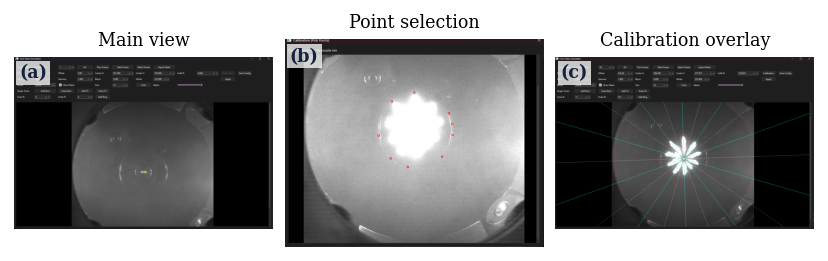

Saved C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\fig_gui_calibration_workflow.png, C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\fig_gui_calibration_workflow.pdf


In [65]:
gui_images = [plt.imread(IMAGE_DIR / name) for name in FIG_GUI_WORKFLOW_PARAMS["inputs"]]
gui_titles = ["Main view", "Point selection", "Calibration overlay"]

fig, axs = plt.subplots(1, 3, figsize=(5.8, 1.85), constrained_layout=True)
for ax, image, title in zip(axs, gui_images, gui_titles):
    ax.imshow(image)
    ax.set_title(title)
    ax.set_axis_off()
add_panel_labels(axs, labels=["a", "b", "c"], x=0.02, y=0.96)
export_figure(fig, FIG_GUI_WORKFLOW_PARAMS["filename"])
plt.close(fig)


### fig_mie_preproc_background_placeholder


In [66]:
FIG_BG_PARAMS = {
    "filename": "fig_mie_preproc_background.png",
    "frame_idx": representative_frame_idx,
}
FIG_BG_PARAMS


{'filename': 'fig_mie_preproc_background.png', 'frame_idx': 30}

In [67]:
fig_bg_data = {
    "raw": video_np[FIG_BG_PARAMS["frame_idx"]],
    "background": background,
    "foreground": foreground_np[FIG_BG_PARAMS["frame_idx"]],
    "source_note": source_note,
}


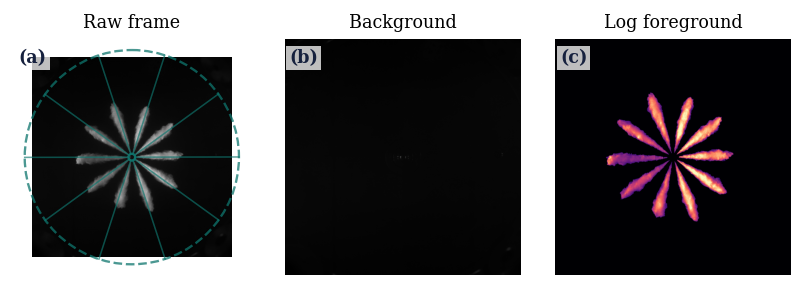

In [68]:
fig, axs = plt.subplots(1, 3, figsize=(5.8, 1.95), constrained_layout=True)
axs[0].imshow(fig_bg_data["raw"], cmap="gray")
axs[0].set_title("Raw frame")
draw_geometry_overlay(axs[0], MIE_GEOMETRY)
axs[1].imshow(fig_bg_data["background"], cmap="gray")
axs[1].set_title("Background")
axs[2].imshow(fig_bg_data["foreground"], cmap="magma", vmin=0, vmax=1)
axs[2].set_title("Log foreground")
for ax in axs:
    ax.set_axis_off()
add_panel_labels(axs, labels=["a", "b", "c"], x=0.02, y=0.96)
plt.show()


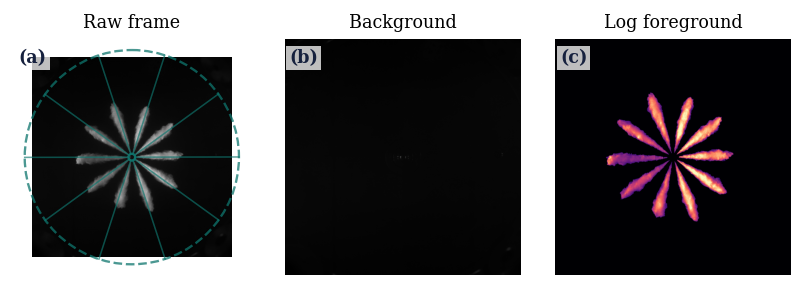

Saved C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\fig_mie_preproc_background.png, C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\fig_mie_preproc_background.pdf


In [69]:
export_figure(fig, FIG_BG_PARAMS["filename"])
plt.close(fig)


### fig_mie_preproc_sobel_placeholder


In [70]:
FIG_SOBEL_PARAMS = {
    "filename": "fig_mie_preproc_sobel.png",
    "frame_idx": representative_frame_idx,
}
FIG_SOBEL_PARAMS


{'filename': 'fig_mie_preproc_sobel.png', 'frame_idx': 30}

In [71]:
fig_sobel_data = {
    "foreground": foreground_np[FIG_SOBEL_PARAMS["frame_idx"]],
    "sobel": sobel_mag[FIG_SOBEL_PARAMS["frame_idx"]],
    "highpass": highpass_np[FIG_SOBEL_PARAMS["frame_idx"]],
}


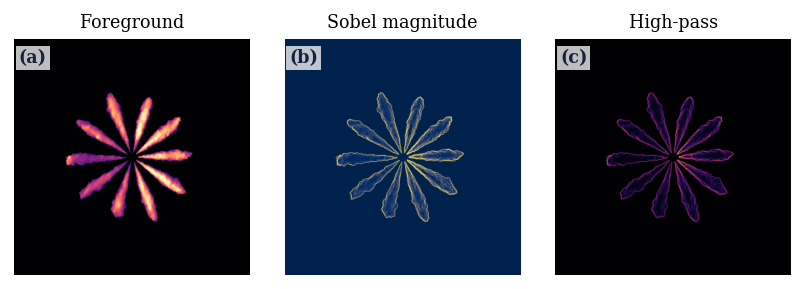

In [72]:
fig, axs = plt.subplots(1, 3, figsize=(5.8, 1.95), constrained_layout=True)
axs[0].imshow(fig_sobel_data["foreground"], cmap="magma", vmin=0, vmax=1)
axs[0].set_title("Foreground")
axs[1].imshow(robust_scale_local(fig_sobel_data["sobel"], q_min=1, q_max=99.8), cmap="cividis", vmin=0, vmax=1)
axs[1].set_title("Sobel magnitude")
axs[2].imshow(fig_sobel_data["highpass"], cmap="inferno", vmin=0, vmax=1)
axs[2].set_title("High-pass")
for ax in axs:
    ax.set_axis_off()
add_panel_labels(axs, labels=["a", "b", "c"], x=0.02, y=0.96)
plt.show()


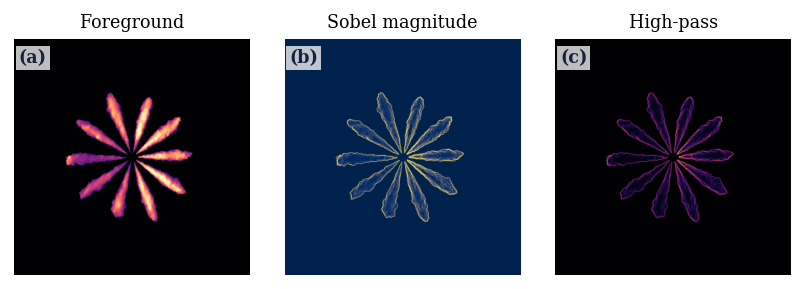

Saved C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\fig_mie_preproc_sobel.png, C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\fig_mie_preproc_sobel.pdf


In [73]:
export_figure(fig, FIG_SOBEL_PARAMS["filename"])
plt.close(fig)


### fig_mie_highpass_histogram

The high-pass foreground is examined inside the annular spray-analysis mask after per-video robust scaling. The expected distribution is single-peaked with most pixels close to zero, supporting a global triangle threshold on the scaled video.


In [74]:
FIG_HIGHPASS_HIST_PARAMS = {
    "filename": "fig_mie_highpass_histogram.png",
    "frame_idx": representative_frame_idx,
    "bins": 256,
    "range": (0.0, 1.0),
}
FIG_HIGHPASS_HIST_PARAMS


{'filename': 'fig_mie_highpass_histogram.png',
 'frame_idx': 30,
 'bins': 256,
 'range': (0.0, 1.0)}

In [75]:
def triangle_threshold_local(values, bins=256, value_range=(0.0, 1.0)):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return float("nan")
    try:
        from skimage.filters import threshold_triangle

        return float(threshold_triangle(values, nbins=bins))
    except Exception:
        hist, edges = np.histogram(values, bins=bins, range=value_range)
        nonzero = np.flatnonzero(hist)
        if nonzero.size < 2:
            return float(edges[nonzero[0] if nonzero.size else 0])
        left = int(nonzero[0])
        right = int(nonzero[-1])
        peak = int(np.argmax(hist))
        end = right if (right - peak) >= (peak - left) else left
        idx = np.arange(min(peak, end), max(peak, end) + 1)
        x1, y1 = float(peak), float(hist[peak])
        x2, y2 = float(end), float(hist[end])
        denom = np.hypot(y2 - y1, x2 - x1)
        if denom == 0:
            threshold_idx = peak
        else:
            distances = np.abs((y2 - y1) * idx - (x2 - x1) * hist[idx] + x2 * y1 - y2 * x1) / denom
            threshold_idx = int(idx[np.argmax(distances)])
        return float(0.5 * (edges[threshold_idx] + edges[threshold_idx + 1]))


highpass_video = to_numpy(highpass_np).astype(float, copy=False)
ring_mask = to_numpy(ring_mask_np).astype(bool, copy=False)
hist_values = highpass_video[:, ring_mask].ravel()
hist_values = hist_values[np.isfinite(hist_values)]
rep_values = highpass_video[FIG_HIGHPASS_HIST_PARAMS["frame_idx"]][ring_mask].ravel()
rep_values = rep_values[np.isfinite(rep_values)]

global_triangle_threshold = triangle_threshold_local(
    hist_values,
    bins=FIG_HIGHPASS_HIST_PARAMS["bins"],
    value_range=FIG_HIGHPASS_HIST_PARAMS["range"],
)
frame_triangle_threshold = triangle_threshold_local(
    rep_values,
    bins=FIG_HIGHPASS_HIST_PARAMS["bins"],
    value_range=FIG_HIGHPASS_HIST_PARAMS["range"],
)

highpass_hist_stats = {
    "pixels_in_histogram": int(hist_values.size),
    "fraction_le_1e-3": float(np.mean(hist_values <= 1e-3)),
    "fraction_le_0.05": float(np.mean(hist_values <= 0.05)),
    "global_triangle_threshold": global_triangle_threshold,
    "frame_triangle_threshold": frame_triangle_threshold,
}
highpass_hist_stats


{'pixels_in_histogram': 51027500,
 'fraction_le_1e-3': 0.8861887805595022,
 'fraction_le_0.05': 0.9486868061339474,
 'global_triangle_threshold': 0.005859375,
 'frame_triangle_threshold': 0.005859375}

In [76]:
from OSCC_postprocessing.playback.video_playback import *
# play_video_cv2(255.0*(highpass_video > global_triangle_threshold), intv=100)

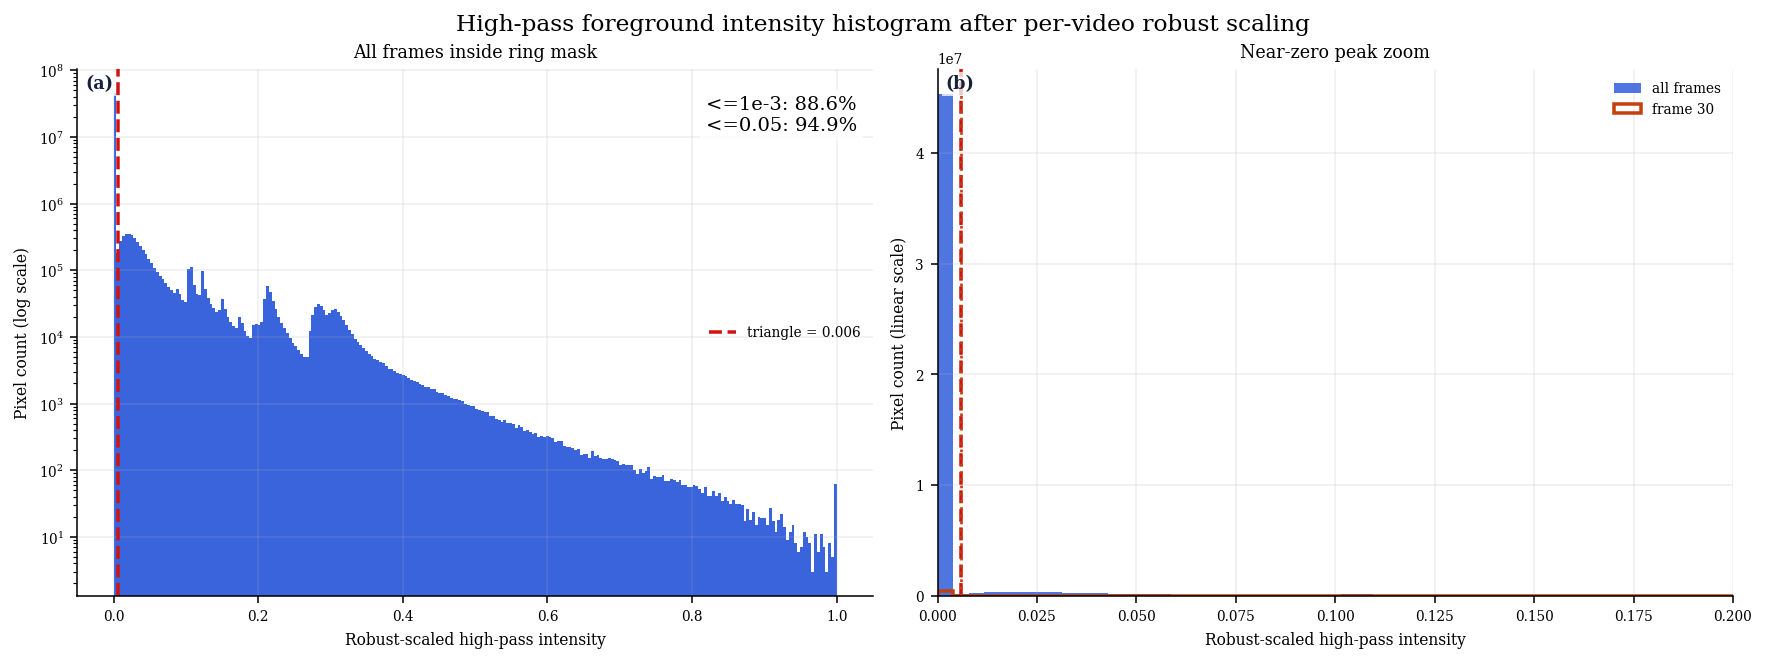

In [77]:
bins = np.linspace(*FIG_HIGHPASS_HIST_PARAMS["range"], FIG_HIGHPASS_HIST_PARAMS["bins"] + 1)
fig, axs = plt.subplots(1, 2, figsize=(12.5, 4.4), constrained_layout=True)

axs[0].hist(hist_values, bins=bins, color=COLORS["blue"], alpha=0.88, log=True)
axs[0].axvline(global_triangle_threshold, color=COLORS["red"], lw=1.8, ls="--", label=f"triangle = {global_triangle_threshold:.3f}")
axs[0].set_title("All frames inside ring mask")
axs[0].set_xlabel("Robust-scaled high-pass intensity")
axs[0].set_ylabel("Pixel count (log scale)")
axs[0].legend(frameon=False)
axs[0].grid(True, alpha=0.20)

axs[1].hist(hist_values, bins=bins, color=COLORS["blue"], alpha=0.78, log=False, label="all frames")
axs[1].hist(rep_values, bins=bins, histtype="step", color=COLORS["warm"], lw=1.8, log=False, label=f"frame {FIG_HIGHPASS_HIST_PARAMS['frame_idx']}")
axs[1].axvline(global_triangle_threshold, color=COLORS["red"], lw=1.8, ls="--")
axs[1].axvline(frame_triangle_threshold, color=COLORS["warm"], lw=1.4, ls=":")
axs[1].set_xlim(0.0, 0.20)
axs[1].set_title("Near-zero peak zoom")
axs[1].set_xlabel("Robust-scaled high-pass intensity")
axs[1].set_ylabel("Pixel count (linear scale)")
axs[1].legend(frameon=False)
axs[1].grid(True, alpha=0.20)

stats_text = (
    f"<=1e-3: {100 * highpass_hist_stats['fraction_le_1e-3']:.1f}%\n"
    f"<=0.05: {100 * highpass_hist_stats['fraction_le_0.05']:.1f}%"
)
axs[0].text(0.98, 0.95, stats_text, transform=axs[0].transAxes, ha="right", va="top", fontsize=10, bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.78, "pad": 3})

fig.suptitle("High-pass foreground intensity histogram after per-video robust scaling", y=1.04)
add_panel_labels(axs, labels=["a", "b"])
plt.show()


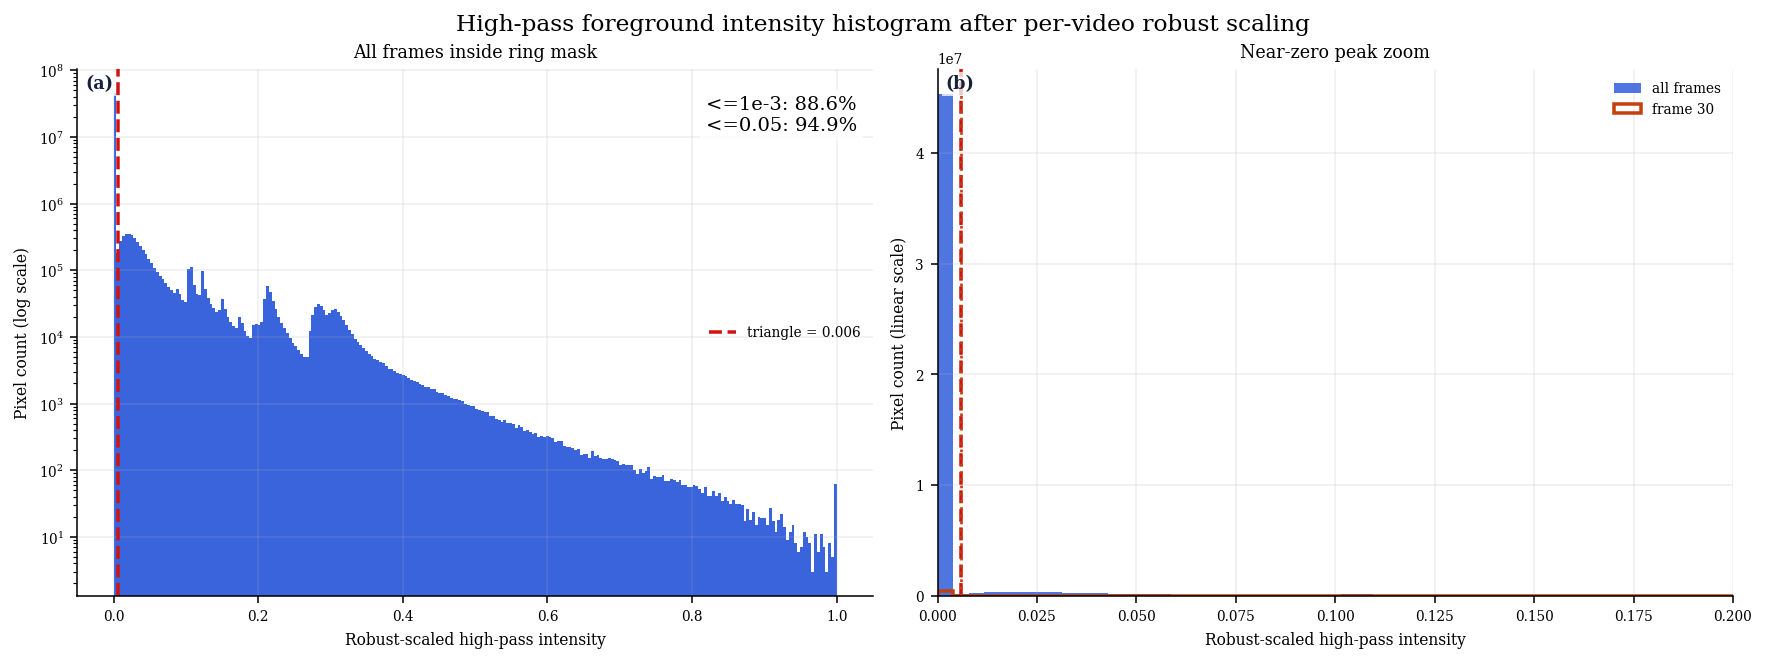

Saved C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\fig_mie_highpass_histogram.png, C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\fig_mie_highpass_histogram.pdf


In [78]:
export_figure(fig, FIG_HIGHPASS_HIST_PARAMS["filename"])
plt.close(fig)


### fig_mie_highpass_bw_frame_compare

Compare the rotated high-pass plume segment with the global-triangle BW mask at several frame indices. The playback cells below use `swapaxes` so the downstream direction is shown from top to bottom instead of left to right.


In [79]:
FIG_BW_HIGHPASS_COMPARE_PARAMS = {
    "filename": "fig_mie_highpass_bw_frame_compare.png",
    "plume_idx": 0,
    "frame_indices": np.unique(np.clip([
        frames_before_soi+5,
        representative_frame_idx,
        representative_frame_idx + 5,
        representative_frame_idx + 15,
    ], 0, num_frames - 1)).astype(int).tolist(),
    "fast_intv_ms": 17,
    "slow_intv_ms": 100,
}
FIG_BW_HIGHPASS_COMPARE_PARAMS


{'filename': 'fig_mie_highpass_bw_frame_compare.png',
 'plume_idx': 0,
 'frame_indices': [25, 30, 35, 45],
 'fast_intv_ms': 17,
 'slow_intv_ms': 100}

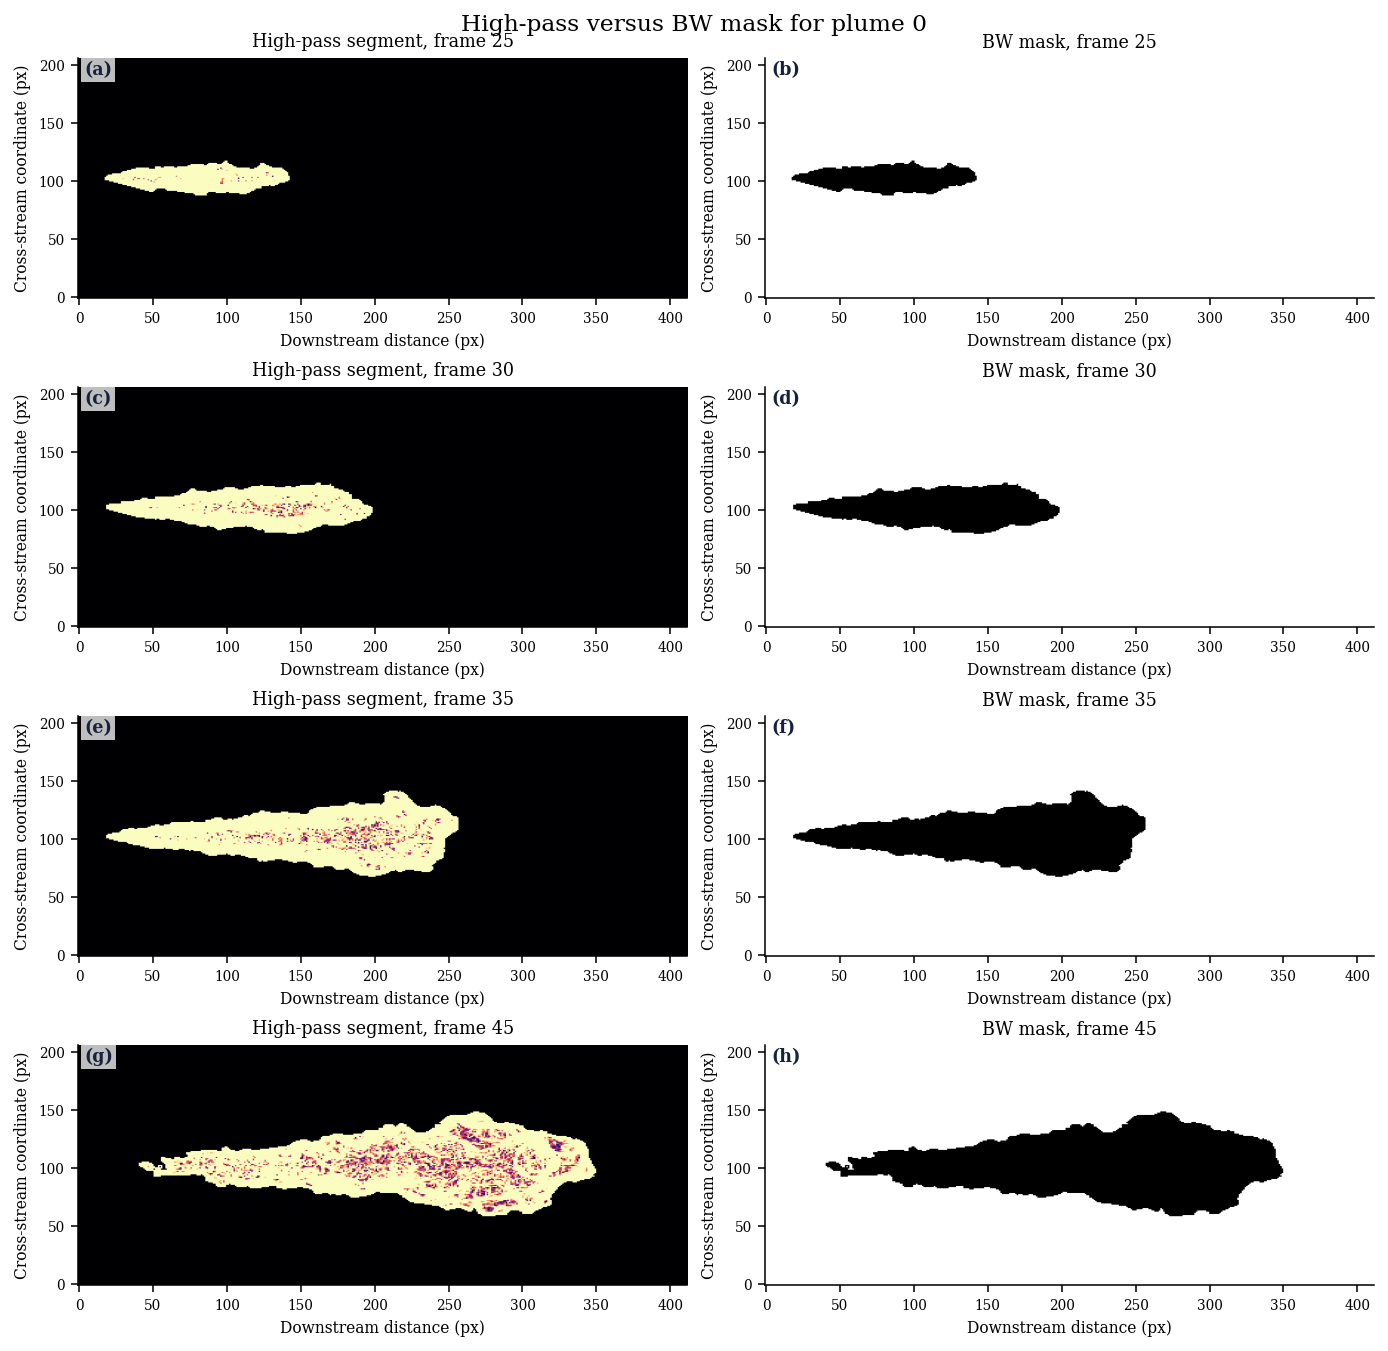

In [80]:
plume_idx_compare = min(int(FIG_BW_HIGHPASS_COMPARE_PARAMS["plume_idx"]), hp_segments_np.shape[0] - 1)
compare_frame_indices = np.asarray(FIG_BW_HIGHPASS_COMPARE_PARAMS["frame_indices"], dtype=int)
compare_frame_indices = np.unique(np.clip(compare_frame_indices, 0, num_frames - 1))

highpass_compare_frames = hp_segments_np[plume_idx_compare, compare_frame_indices]
bw_compare_frames = hp_segments_bw_np[plume_idx_compare, compare_frame_indices]

fig, axs = plt.subplots(len(compare_frame_indices), 2, figsize=(9.8, 2.35 * len(compare_frame_indices)), squeeze=False, constrained_layout=True)
for row_idx, frame_idx in enumerate(compare_frame_indices):
    highpass_img = robust_scale_local(highpass_compare_frames[row_idx], q_min=1.0, q_max=99.9)
    bw_img = bw_compare_frames[row_idx]

    axs[row_idx, 0].imshow(highpass_img, cmap="magma", aspect="auto", origin="lower")
    axs[row_idx, 0].set_title(f"High-pass segment, frame {frame_idx}")
    axs[row_idx, 1].imshow(bw_img, cmap="gray_r", aspect="auto", origin="lower")
    axs[row_idx, 1].set_title(f"BW mask, frame {frame_idx}")

    for ax in axs[row_idx]:
        ax.set_xlabel("Downstream distance (px)")
        ax.set_ylabel("Cross-stream coordinate (px)")

fig.suptitle(f"High-pass versus BW mask for plume {plume_idx_compare}", y=1.01)
add_panel_labels(axs, labels=list("abcdefghijklmnopqrstuvwxyz")[: axs.size])
fig_highpass_bw_compare = fig
plt.show()


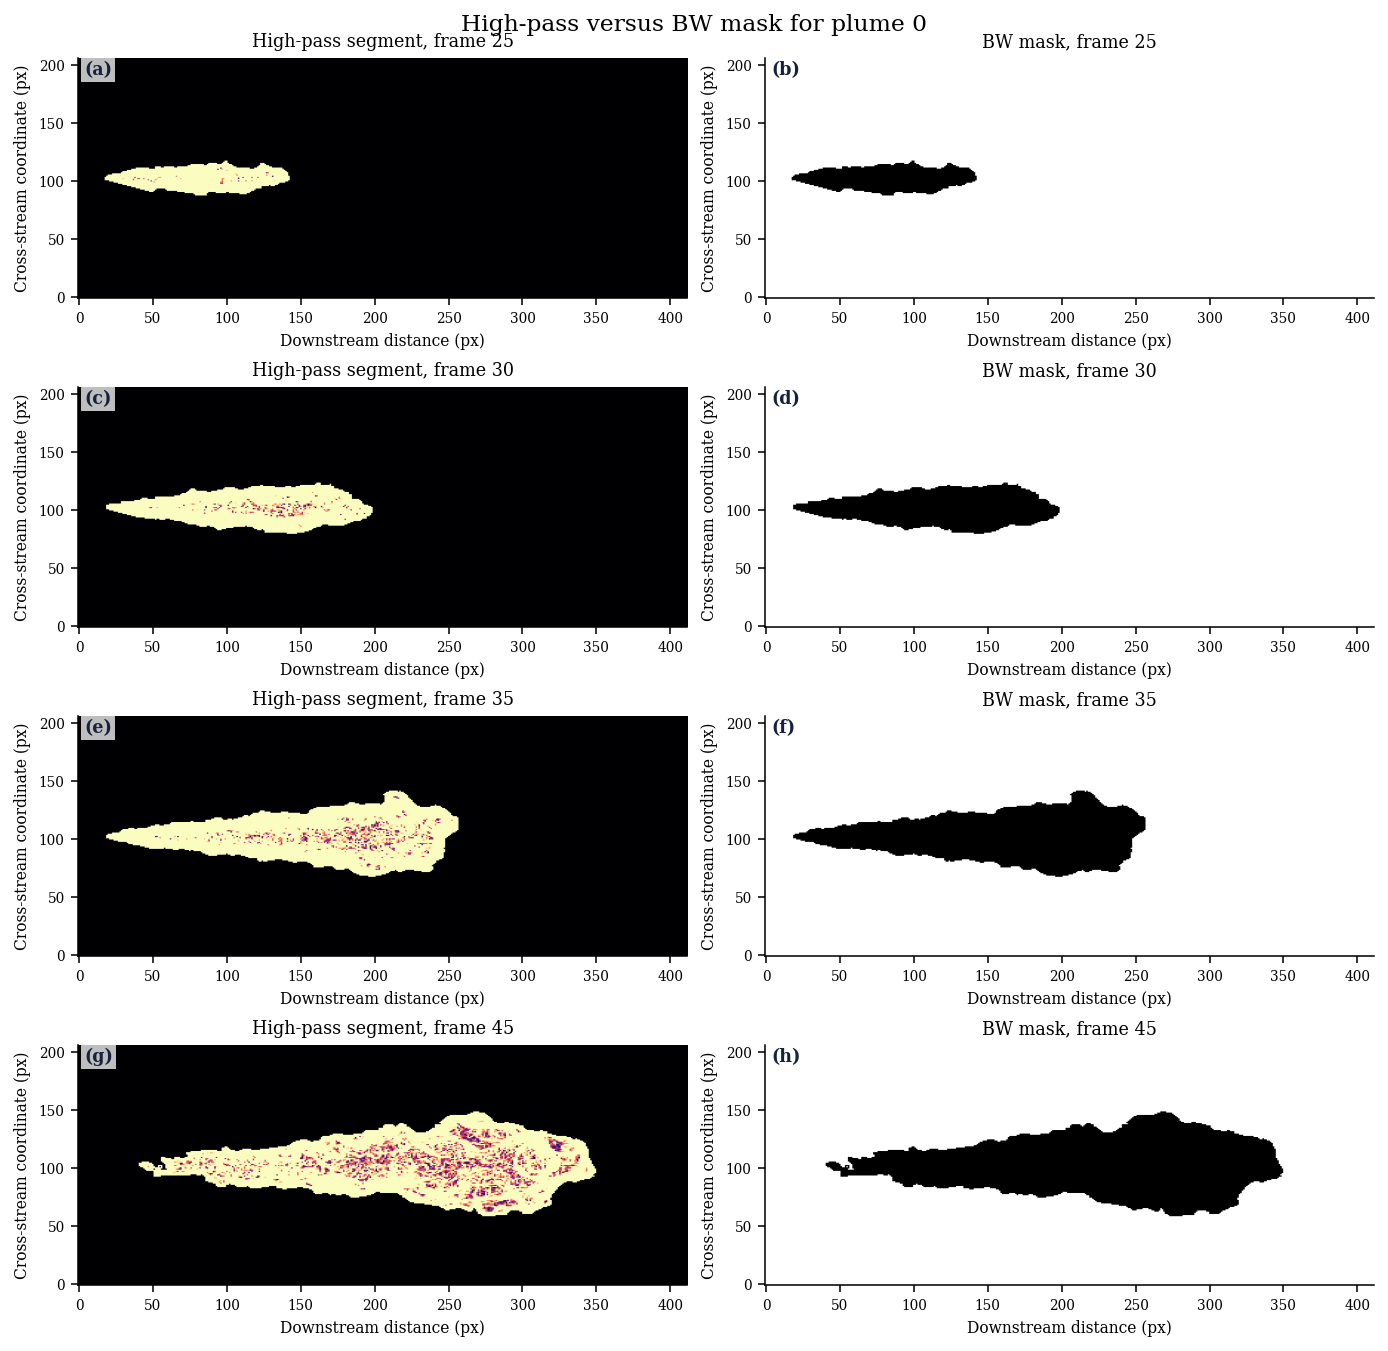

Saved C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\fig_mie_highpass_bw_frame_compare.png, C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\fig_mie_highpass_bw_frame_compare.pdf


In [81]:
export_figure(fig_highpass_bw_compare, FIG_BW_HIGHPASS_COMPARE_PARAMS["filename"])
plt.close(fig_highpass_bw_compare)


In [82]:
highpass_topdown_video = np.swapaxes(
    255.0 * robust_scale_local(hp_segments_np[plume_idx_compare], q_min=1.0, q_max=99.8),
    1,
    2,
)
bw_topdown_video = np.swapaxes(
    255.0 * hp_segments_bw_np[plume_idx_compare].astype(float),
    1,
    2,
)

compare_topdown_videos = [highpass_topdown_video, bw_topdown_video]
print(
    "Prepared top-down playback videos:",
    f"highpass={highpass_topdown_video.shape}, bw={bw_topdown_video.shape}",
)


Prepared top-down playback videos: highpass=(100, 412, 206), bw=(100, 412, 206)


In [83]:
if repo_playback is not None and hasattr(repo_playback, "play_videos_side_by_side"):
    repo_playback.play_videos_side_by_side(
        compare_topdown_videos,
        gain=1.0,
        intv=FIG_BW_HIGHPASS_COMPARE_PARAMS["fast_intv_ms"],
    )
else:
    print("Playback helper is unavailable in this kernel.")


In [84]:
if repo_playback is not None and hasattr(repo_playback, "play_videos_side_by_side"):
    repo_playback.play_videos_side_by_side(
        compare_topdown_videos,
        gain=1.0,
        intv=FIG_BW_HIGHPASS_COMPARE_PARAMS["slow_intv_ms"],
    )
else:
    print("Playback helper is unavailable in this kernel.")


### fig_mie_bw_repair_demo

This panel shows the optional BW repair sequence used for plume masks: binary closing, hole filling, largest 3-D connected component selection, and a final largest-component cleanup on each frame.


In [85]:
FIG_BW_REPAIR_PARAMS = {
    "filename": "fig_mie_bw_repair_demo.png",
    "plume_idx": 0,
    "frame_idx": representative_frame_idx,
}
FIG_BW_REPAIR_PARAMS


{'filename': 'fig_mie_bw_repair_demo.png', 'plume_idx': 0, 'frame_idx': 30}

In [86]:
bw_raw = to_numpy(hp_segments_bw_raw).astype(bool, copy=False)
bw_repaired = to_numpy(mmh.repair_binary_plume_video(hp_segments_bw_raw)).astype(bool, copy=False)

plume_idx = min(int(FIG_BW_REPAIR_PARAMS["plume_idx"]), bw_raw.shape[0] - 1)
frame_idx = min(int(FIG_BW_REPAIR_PARAMS["frame_idx"]), bw_raw.shape[1] - 1)
raw_frame = bw_raw[plume_idx, frame_idx]
repaired_frame = bw_repaired[plume_idx, frame_idx]
delta_frame = repaired_frame.astype(np.int8) - raw_frame.astype(np.int8)

bw_repair_stats = {
    "plume_idx": plume_idx,
    "frame_idx": frame_idx,
    "raw_pixels_frame": int(raw_frame.sum()),
    "repaired_pixels_frame": int(repaired_frame.sum()),
    "added_pixels_frame": int((delta_frame > 0).sum()),
    "removed_pixels_frame": int((delta_frame < 0).sum()),
    "raw_pixels_video": int(bw_raw.sum()),
    "repaired_pixels_video": int(bw_repaired.sum()),
}
bw_repair_stats


{'plume_idx': 0,
 'frame_idx': 30,
 'raw_pixels_frame': 4959,
 'repaired_pixels_frame': 4995,
 'added_pixels_frame': 36,
 'removed_pixels_frame': 0,
 'raw_pixels_video': 5809184,
 'repaired_pixels_video': 5869373}

### fig_threshold_mask_repair_summary

Compact thesis panel connecting robust high-pass scaling, triangle thresholding, binary support, and BW repair.


In [87]:
FIG_THRESHOLD_MASK_REPAIR_PARAMS = {
    "filename": "fig_threshold_mask_repair_summary.png",
    "plume_idx": plume_idx,
    "frame_idx": frame_idx,
    "bins": FIG_HIGHPASS_HIST_PARAMS["bins"],
    "range": FIG_HIGHPASS_HIST_PARAMS["range"],
}
FIG_THRESHOLD_MASK_REPAIR_PARAMS


{'filename': 'fig_threshold_mask_repair_summary.png',
 'plume_idx': 0,
 'frame_idx': 30,
 'bins': 256,
 'range': (0.0, 1.0)}

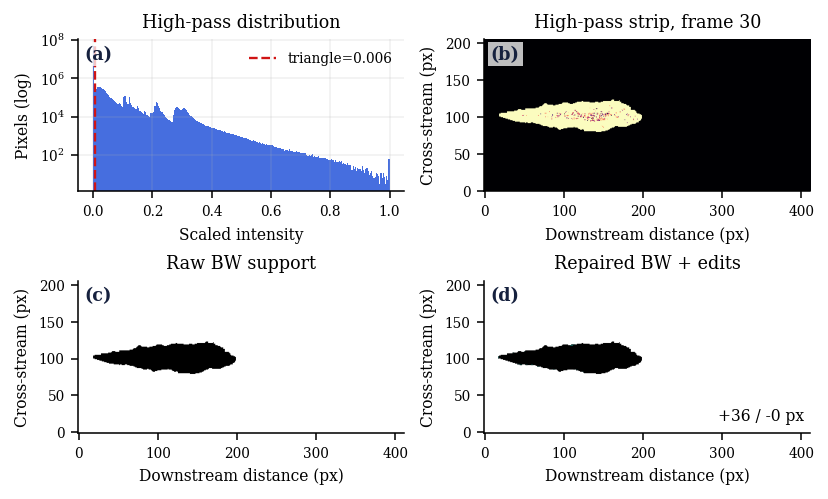

Saved C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\fig_threshold_mask_repair_summary.png, C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\fig_threshold_mask_repair_summary.pdf


In [88]:
from matplotlib import colors as mcolors

bins = np.linspace(*FIG_THRESHOLD_MASK_REPAIR_PARAMS["range"], FIG_THRESHOLD_MASK_REPAIR_PARAMS["bins"] + 1)
delta_cmap = mcolors.ListedColormap([COLORS["red"], (1, 1, 1, 0), COLORS["accent"]])
delta_norm = mcolors.BoundaryNorm([-1.5, -0.5, 0.5, 1.5], delta_cmap.N)

highpass_strip = robust_scale_local(hp_segments_np[plume_idx, frame_idx], q_min=1.0, q_max=98.0)
repaired_with_edits = np.ma.masked_where(delta_frame == 0, delta_frame)

fig = plt.figure(figsize=(5.8, 3.45), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.0])
axs = np.array([
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
])

axs[0].hist(hist_values, bins=bins, color=COLORS["blue"], alpha=0.82, log=True)
axs[0].axvline(global_triangle_threshold, color=COLORS["red"], lw=1.2, ls="--", label=f"triangle={global_triangle_threshold:.3f}")
axs[0].set_title("High-pass distribution")
axs[0].set_xlabel("Scaled intensity")
axs[0].set_ylabel("Pixels (log)")
axs[0].legend(frameon=False, loc="upper right")
axs[0].grid(True, alpha=0.18)

axs[1].imshow(highpass_strip, cmap="magma", aspect="auto", origin="lower", vmin=0, vmax=1)
axs[1].set_title(f"High-pass strip, frame {frame_idx}")
axs[1].set_xlabel("Downstream distance (px)")
axs[1].set_ylabel("Cross-stream (px)")

axs[2].imshow(raw_frame, cmap="gray_r", aspect="auto", origin="lower")
axs[2].set_title("Raw BW support")
axs[2].set_xlabel("Downstream distance (px)")
axs[2].set_ylabel("Cross-stream (px)")

axs[3].imshow(repaired_frame, cmap="gray_r", aspect="auto", origin="lower")
axs[3].imshow(repaired_with_edits, cmap=delta_cmap, norm=delta_norm, aspect="auto", origin="lower", alpha=0.9)
axs[3].set_title("Repaired BW + edits")
axs[3].set_xlabel("Downstream distance (px)")
axs[3].set_ylabel("Cross-stream (px)")
axs[3].text(
    0.98,
    0.05,
    f"+{bw_repair_stats['added_pixels_frame']} / -{bw_repair_stats['removed_pixels_frame']} px",
    transform=axs[3].transAxes,
    ha="right",
    va="bottom",
    fontsize=8,
    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.8, "pad": 2},
)

add_panel_labels(axs, labels=["a", "b", "c", "d"], x=0.02, y=0.96)
export_figure(fig, FIG_THRESHOLD_MASK_REPAIR_PARAMS["filename"])
plt.close(fig)


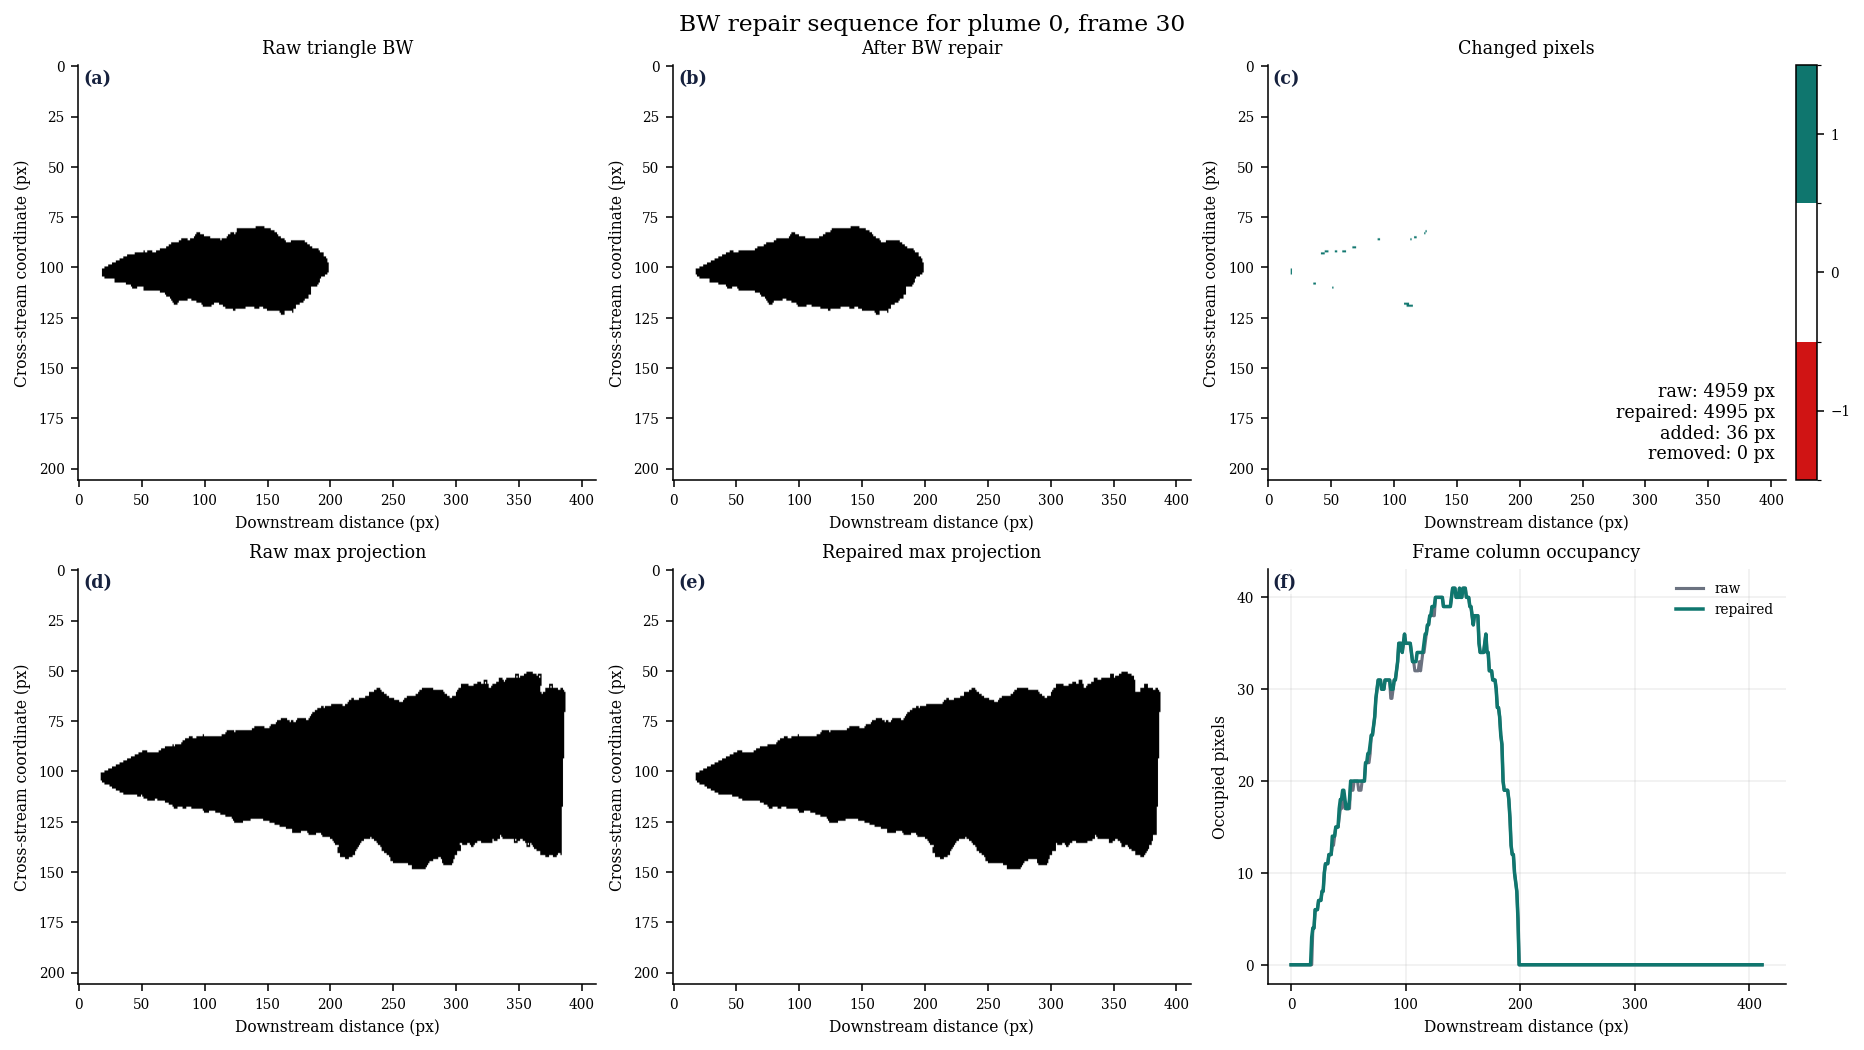

In [89]:
from matplotlib import colors as mcolors

delta_cmap = mcolors.ListedColormap([COLORS["red"], "white", COLORS["accent"]])
delta_norm = mcolors.BoundaryNorm([-1.5, -0.5, 0.5, 1.5], delta_cmap.N)
raw_projection = bw_raw[plume_idx].max(axis=0)
repaired_projection = bw_repaired[plume_idx].max(axis=0)
raw_col_sum = raw_frame.sum(axis=0)
repaired_col_sum = repaired_frame.sum(axis=0)

fig, axs = plt.subplots(2, 3, figsize=(13.2, 7.2), constrained_layout=True)
axs[0, 0].imshow(raw_frame, cmap="gray_r", aspect="auto")
axs[0, 0].set_title("Raw triangle BW")
axs[0, 1].imshow(repaired_frame, cmap="gray_r", aspect="auto")
axs[0, 1].set_title("After BW repair")
im_delta = axs[0, 2].imshow(delta_frame, cmap=delta_cmap, norm=delta_norm, aspect="auto")
axs[0, 2].set_title("Changed pixels")
plt.colorbar(im_delta, ax=axs[0, 2], fraction=0.046, pad=0.02, ticks=[-1, 0, 1])

axs[1, 0].imshow(raw_projection, cmap="gray_r", aspect="auto")
axs[1, 0].set_title("Raw max projection")
axs[1, 1].imshow(repaired_projection, cmap="gray_r", aspect="auto")
axs[1, 1].set_title("Repaired max projection")
axs[1, 2].plot(raw_col_sum, color=COLORS["gray"], lw=1.6, label="raw")
axs[1, 2].plot(repaired_col_sum, color=COLORS["accent"], lw=1.8, label="repaired")
axs[1, 2].set_title("Frame column occupancy")
axs[1, 2].set_xlabel("Downstream distance (px)")
axs[1, 2].set_ylabel("Occupied pixels")
axs[1, 2].legend(frameon=False)
axs[1, 2].grid(True, alpha=0.20)

for ax in axs.ravel()[:5]:
    ax.set_xlabel("Downstream distance (px)")
    ax.set_ylabel("Cross-stream coordinate (px)")

stats_text = (
    f"raw: {bw_repair_stats['raw_pixels_frame']} px\n"
    f"repaired: {bw_repair_stats['repaired_pixels_frame']} px\n"
    f"added: {bw_repair_stats['added_pixels_frame']} px\n"
    f"removed: {bw_repair_stats['removed_pixels_frame']} px"
)
axs[0, 2].text(0.98, 0.04, stats_text, transform=axs[0, 2].transAxes, ha="right", va="bottom", fontsize=9, bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.82, "pad": 3})
fig.suptitle(f"BW repair sequence for plume {plume_idx}, frame {frame_idx}", y=1.02)
add_panel_labels(axs, labels=list("abcdef"))
plt.show()


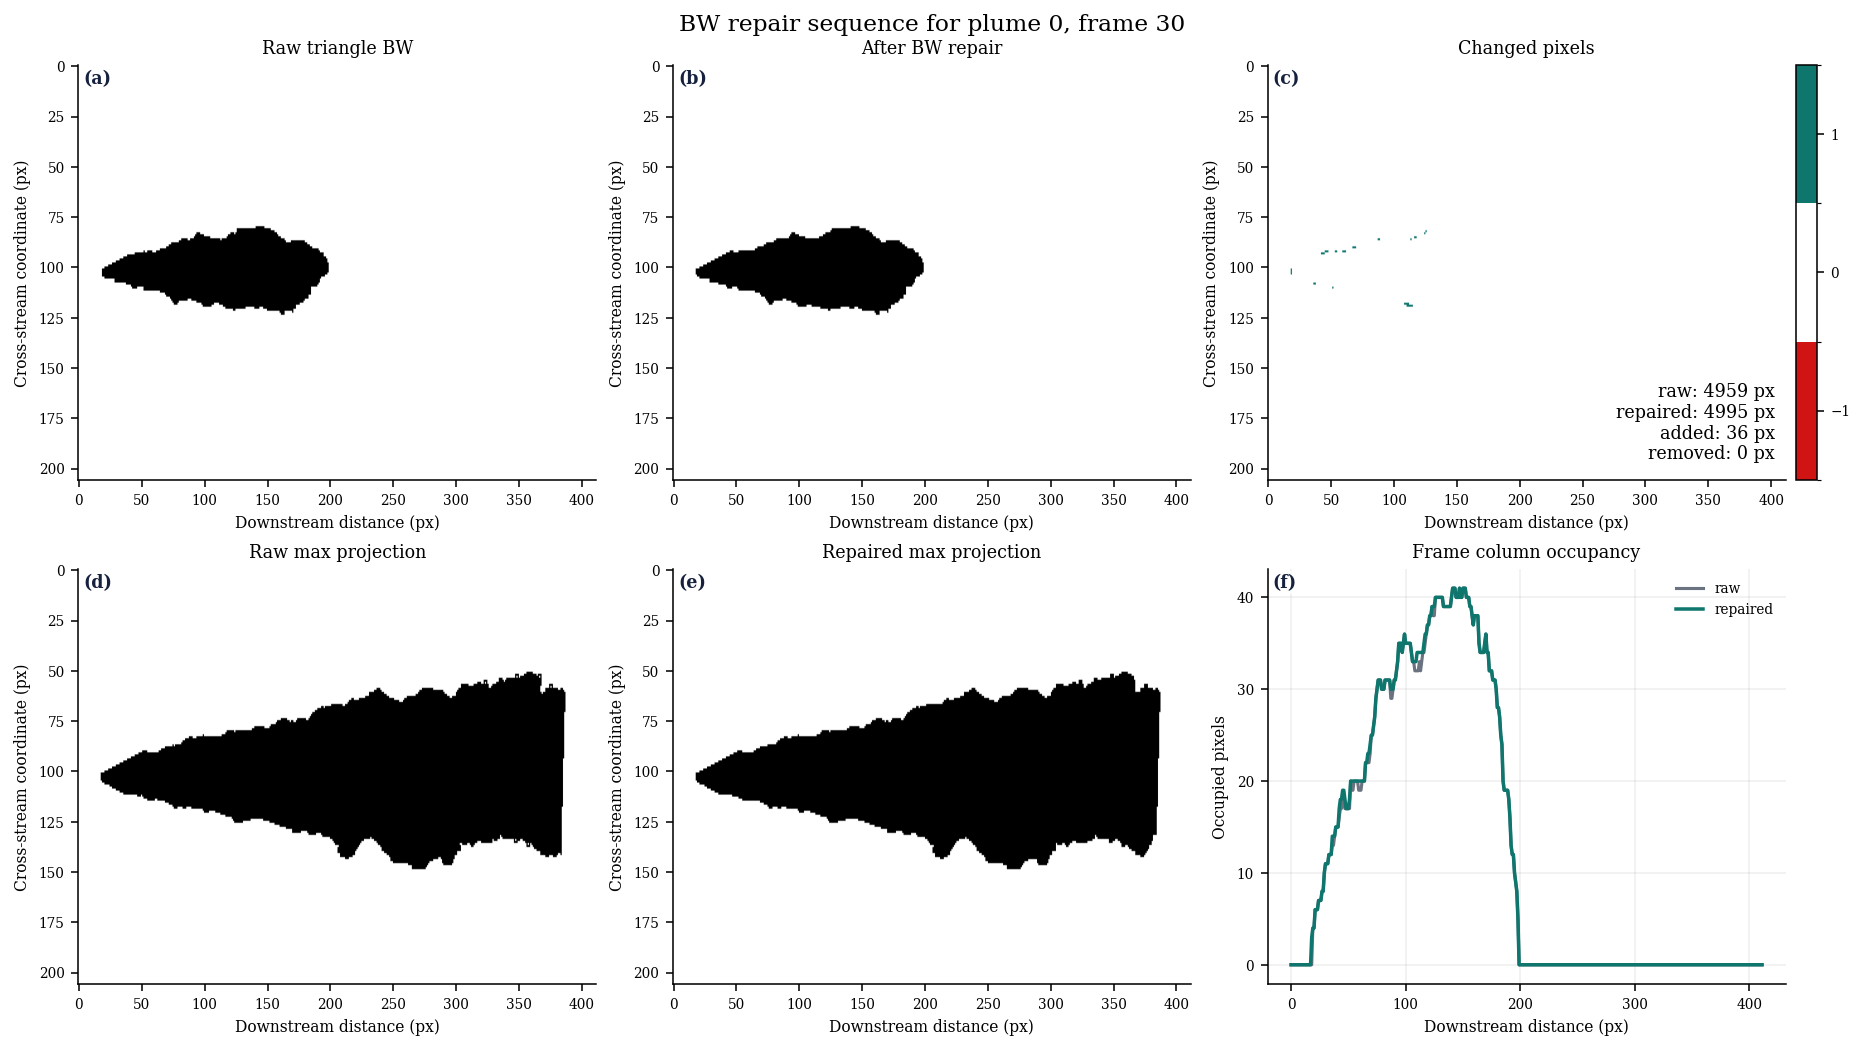

Saved C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\fig_mie_bw_repair_demo.png, C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\fig_mie_bw_repair_demo.pdf


In [90]:
export_figure(fig, FIG_BW_REPAIR_PARAMS["filename"])
plt.close(fig)


### fig_angular_occupancy_placeholder


In [91]:
FIG_ANGULAR_PARAMS = {
    "filename": "fig_angular_occupancy.png",
    "comparison_filename": "fig_angular_mask_comparison.png",
    "max_harmonic": 40,
}
FIG_ANGULAR_PARAMS


{'filename': 'fig_angular_occupancy.png',
 'comparison_filename': 'fig_angular_mask_comparison.png',
 'max_harmonic': 40}

In [92]:
fft_vals = np.fft.rfft(summed_profile)
fft_amp = np.abs(fft_vals)
harmonics = np.arange(len(fft_amp))
occupancy_segments = periodic_true_segments(occupancy_mask, angle_bins)
occupancy_segment_widths_deg = periodic_true_segment_angles(occupancy_mask, angle_bins)
occupied_bin_count = int(np.count_nonzero(occupancy_mask))
total_occupied_angle_deg = float(occupied_bin_count * 360.0 / len(occupancy_mask))
cone_angle_proxy_deg = float(occupancy_segment_widths_deg.mean()) if occupancy_segment_widths_deg.size else 0.0
fig_angular_data = {
    "profiles": angle_signal,
    "bins": angle_bins,
    "summed_profile": summed_profile,
    "fft_amp": fft_amp,
    "harmonics": harmonics,
    "offset": fft_offset,
    "occupancy_mask": occupancy_mask,
    "occupancy_segments": occupancy_segments,
    "occupancy_segment_widths_deg": occupancy_segment_widths_deg,
    "occupied_bin_count": occupied_bin_count,
    "total_occupied_angle_deg": total_occupied_angle_deg,
    "cone_angle_proxy_deg": cone_angle_proxy_deg,
    "plume_angles": plume_angles,
}


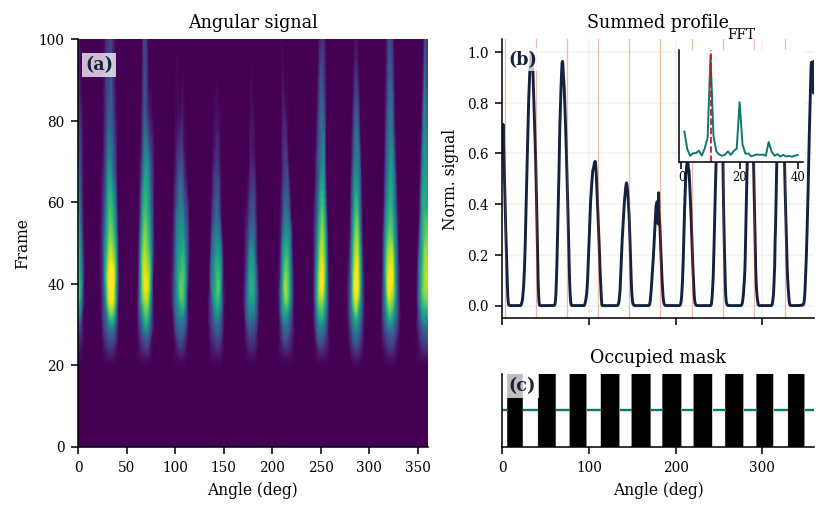

In [93]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

profile_scaled = robust_scale_local(
    fig_angular_data["summed_profile"],
    q_min=q_min_angular_profile,
    q_max=q_max_angular_profile,
)
profiles_scaled = robust_scale_local(
    fig_angular_data["profiles"],
    q_min=q_min_angular_profile,
    q_max=q_max_angular_profile,
)
max_harmonic = min(FIG_ANGULAR_PARAMS["max_harmonic"], len(fig_angular_data["fft_amp"]) - 1)

fig = plt.figure(figsize=(5.8, 3.55), constrained_layout=True)
gs = fig.add_gridspec(2, 2, width_ratios=[1.12, 1.0], height_ratios=[1.0, 0.26])
ax_heat = fig.add_subplot(gs[:, 0])
ax_profile = fig.add_subplot(gs[0, 1])
ax_mask = fig.add_subplot(gs[1, 1])

im = ax_heat.imshow(
    profiles_scaled,
    aspect="auto",
    origin="lower",
    cmap="viridis",
    extent=[0.0, 360.0, 0, fig_angular_data["profiles"].shape[0]],
)
ax_heat.set_title("Angular signal")
ax_heat.set_xlabel("Angle (deg)")
ax_heat.set_ylabel("Frame")

ax_profile.plot(fig_angular_data["bins"], profile_scaled, color=COLORS["ink"], lw=1.5)
for angle in fig_angular_data["plume_angles"]:
    ax_profile.axvline(angle % 360.0, color=COLORS["warm"], lw=0.65, alpha=0.35)
ax_profile.set_xlim(0.0, 360.0)
ax_profile.set_title("Summed profile")
ax_profile.set_ylabel("Norm. signal")
ax_profile.set_xticklabels([])
ax_profile.grid(True, alpha=0.16)

ax_fft = inset_axes(ax_profile, width="40%", height="40%", loc="upper right", borderpad=0.8)
ax_fft.plot(
    fig_angular_data["harmonics"][1:max_harmonic + 1],
    fig_angular_data["fft_amp"][1:max_harmonic + 1],
    color=COLORS["accent"],
    lw=1.0,
)
ax_fft.axvline(MIE_GEOMETRY["plumes"], color=COLORS["red"], lw=0.9, ls="--")
ax_fft.set_title("FFT", fontsize=7)
ax_fft.set_xlabel("")
ax_fft.set_yticks([])
ax_fft.tick_params(axis="x", labelsize=6, pad=1)

ax_mask.imshow(
    ~fig_angular_data["occupancy_mask"][None, :],
    aspect="auto",
    cmap="gray_r",
    extent=[0.0, 360.0, 0.0, 1.0],
)
for segment in fig_angular_data.get("occupancy_segments", []):
    start_deg = float(segment["start_deg"])
    stop_deg = float(segment["stop_deg"])
    width_deg = float(segment["width_deg"])
    if segment.get("wraps") and width_deg < 360.0:
        ax_mask.hlines(0.5, start_deg, 360.0, colors=COLORS["accent"], lw=1.2)
        ax_mask.hlines(0.5, 0.0, stop_deg, colors=COLORS["accent"], lw=1.2)
    else:
        ax_mask.hlines(0.5, start_deg, start_deg + width_deg, colors=COLORS["accent"], lw=1.2)
ax_mask.set_xlim(0.0, 360.0)
ax_mask.set_ylim(0.0, 1.0)
ax_mask.set_yticks([])
ax_mask.set_title("Occupied mask")
ax_mask.set_xlabel("Angle (deg)")

add_panel_labels([ax_heat, ax_profile, ax_mask], labels=["a", "b", "c"], x=0.02, y=0.96)
fig_angular_main = fig
plt.show()


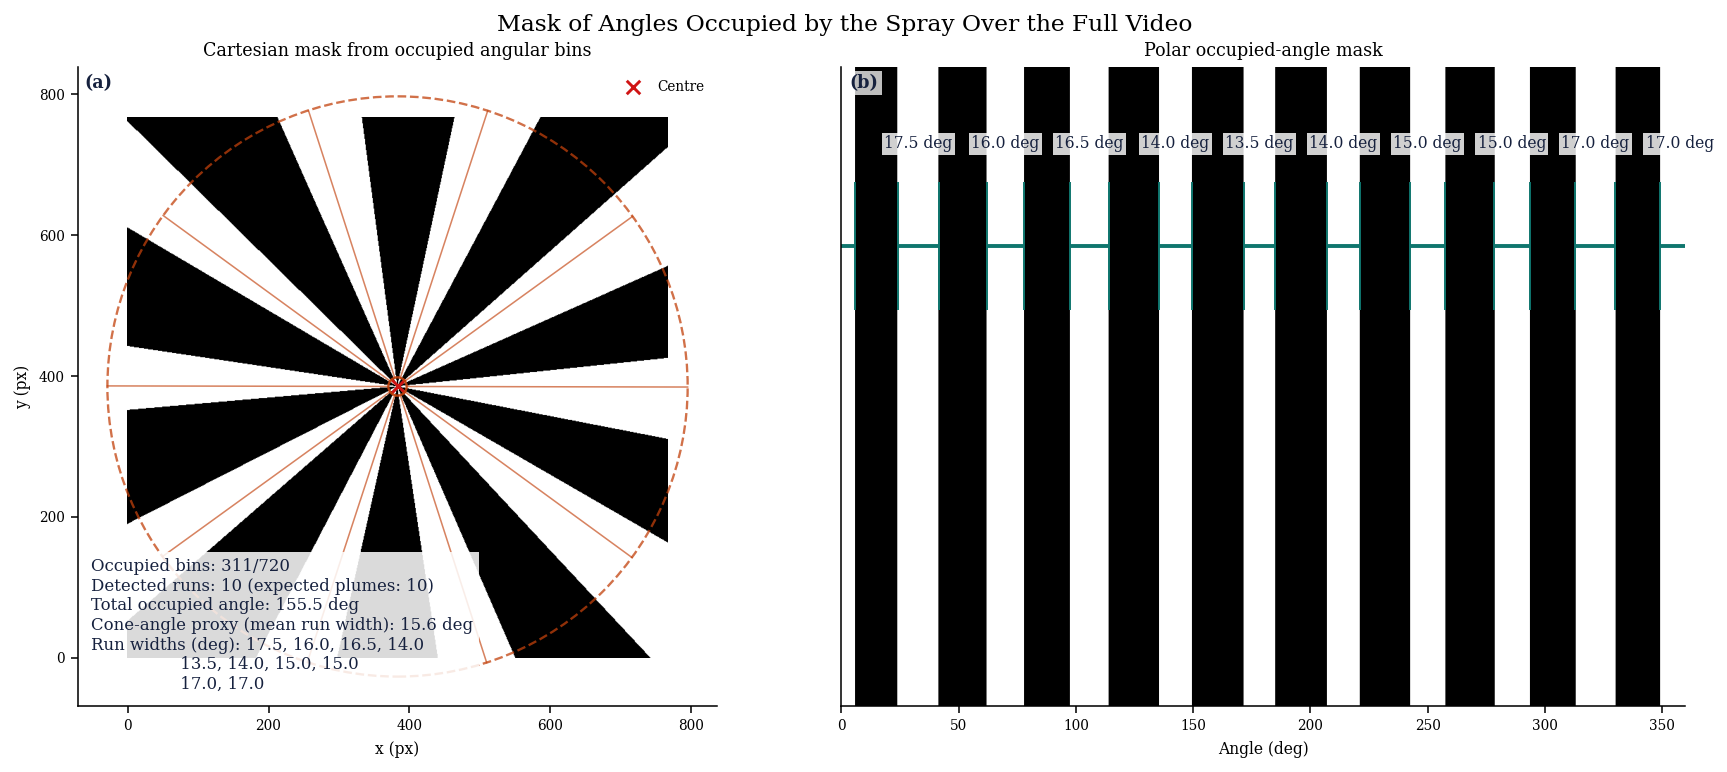

In [94]:
def generate_angular_mask_from_tf_local(H, W, centre, TF, bins):
    yy, xx = np.indices((H, W))
    dx = xx - float(centre[0])
    dy = yy - float(centre[1])
    angles = (np.degrees(np.arctan2(dy, dx)) + 360.0) % 360.0
    bin_indices = np.clip((angles / 360.0 * bins).astype(np.int32), 0, bins - 1)
    tf = np.asarray(TF)
    if tf.ndim != 1:
        tf = np.squeeze(tf)
    return tf[bin_indices]


legacy_angular_mask = generate_angular_mask_from_tf_local(
    video_np.shape[1],
    video_np.shape[2],
    MIE_GEOMETRY["centre"],
    fig_angular_data["occupancy_mask"].astype(float),
    len(fig_angular_data["bins"]),
)
width_strings = [f"{width:.1f}" for width in fig_angular_data["occupancy_segment_widths_deg"]]
summary_lines = [
    f"Occupied bins: {fig_angular_data['occupied_bin_count']}/{len(fig_angular_data['occupancy_mask'])}",
    f"Detected runs: {len(fig_angular_data['occupancy_segments'])} (expected plumes: {MIE_GEOMETRY['plumes']})",
    f"Total occupied angle: {fig_angular_data['total_occupied_angle_deg']:.1f} deg",
    f"Cone-angle proxy (mean run width): {fig_angular_data['cone_angle_proxy_deg']:.1f} deg",
]
for start in range(0, len(width_strings), 4):
    prefix = "Run widths (deg): " if start == 0 else " " * 17
    summary_lines.append(prefix + ", ".join(width_strings[start:start + 4]))

fig, axs = plt.subplots(1, 2, figsize=(12.5, 5.2), constrained_layout=True)
axs[0].imshow(legacy_angular_mask, cmap="gray", origin="lower")
axs[0].scatter(MIE_GEOMETRY["centre"][0], MIE_GEOMETRY["centre"][1], c=COLORS["red"], marker="x", s=48, linewidths=1.5, label="Centre")
draw_geometry_overlay(axs[0], MIE_GEOMETRY, color=COLORS["warm"])
axs[0].set_title("Cartesian mask from occupied angular bins")
axs[0].set_xlabel("x (px)")
axs[0].set_ylabel("y (px)")
axs[0].legend(frameon=False, loc="upper right")
axs[0].text(
    0.02,
    0.02,
    "\n".join(summary_lines),
    transform=axs[0].transAxes,
    ha="left",
    va="bottom",
    fontsize=8.5,
    color=COLORS["ink"],
    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.86, "pad": 3.0},
)

axs[1].imshow(~fig_angular_data["occupancy_mask"][None, :], aspect="auto", cmap="gray_r", extent=[0.0, 360.0, 0.0, 1.0])
for segment in fig_angular_data["occupancy_segments"]:
    start_deg = float(segment["start_deg"])
    stop_deg = float(segment["stop_deg"])
    width_deg = float(segment["width_deg"])
    center_deg = float(segment["center_deg"])
    if segment["wraps"] and width_deg < 360.0:
        axs[1].hlines(0.72, start_deg, 360.0, colors=COLORS["accent"], lw=2.0)
        axs[1].hlines(0.72, 0.0, stop_deg, colors=COLORS["accent"], lw=2.0)
        axs[1].vlines([start_deg, stop_deg], 0.62, 0.82, colors=COLORS["accent"], lw=1.0)
    else:
        axs[1].hlines(0.72, start_deg, start_deg + width_deg, colors=COLORS["accent"], lw=2.0)
        axs[1].vlines([start_deg, stop_deg], 0.62, 0.82, colors=COLORS["accent"], lw=1.0)
    axs[1].text(
        center_deg,
        0.88,
        f"{width_deg:.1f} deg",
        ha="center",
        va="center",
        fontsize=8,
        color=COLORS["ink"],
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.82, "pad": 1.2},
    )
axs[1].set_title("Polar occupied-angle mask")
axs[1].set_xlabel("Angle (deg)")
axs[1].set_xlim(0.0, 360.0)
axs[1].set_ylim(0.0, 1.0)
axs[1].set_yticks([])

fig.suptitle("Mask of Angles Occupied by the Spray Over the Full Video", y=1.03)
add_panel_labels(axs, labels=["a", "b"])
fig_angular_compare = fig
plt.show()


In [95]:
export_figure(fig_angular_main, FIG_ANGULAR_PARAMS["filename"], show_inline=False)
if "fig_angular_compare" in globals():
    export_figure(fig_angular_compare, FIG_ANGULAR_PARAMS["comparison_filename"], show_inline=False)
    plt.close(fig_angular_compare)
plt.close(fig_angular_main)


Saved C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\fig_angular_occupancy.png, C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\fig_angular_occupancy.pdf
Saved C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\fig_angular_mask_comparison.png, C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\fig_angular_mask_comparison.pdf


### fig_efficient_rotation_placeholder


In [96]:
FIG_ROTATION_PARAMS = {
    "filename": "fig_efficient_rotation.png",
}
FIG_ROTATION_PARAMS


{'filename': 'fig_efficient_rotation.png'}

In [97]:
reference_angle = float(plume_angles[0])
rotation_out_shape = (int(MIE_GEOMETRY["outer_radius"]) // 2, int(MIE_GEOMETRY["outer_radius"]))
if repo_rotate is not None and hasattr(repo_rotate, "rotate_video_nozzle_at_0_half_numpy"):
    rotated_video, mapx, mapy = repo_rotate.rotate_video_nozzle_at_0_half_numpy(
        highpass_np.astype(np.float32, copy=False),
        MIE_GEOMETRY["centre"],
        reference_angle,
        interpolation=interpolation_mode,
        out_shape=rotation_out_shape,
        border_mode=border_mode,
        cval=0.0,
        stack=True,
        plot_maps=False,
    )
else:
    y0 = int(round(MIE_GEOMETRY["centre"][1]))
    x0 = int(round(MIE_GEOMETRY["centre"][0]))
    strip_h, strip_w = rotation_out_shape
    y1 = max(0, y0 - strip_h // 2)
    y2 = min(highpass_np.shape[1], y1 + strip_h)
    x1 = max(0, x0)
    x2 = min(highpass_np.shape[2], x1 + strip_w)
    rotated_video = np.zeros((highpass_np.shape[0], strip_h, strip_w), dtype=highpass_np.dtype)
    rotated_video[:, : y2 - y1, : x2 - x1] = highpass_np[:, y1:y2, x1:x2]
    mapx, mapy = np.meshgrid(np.arange(strip_w) + x1, np.arange(strip_h) + y1)

rotated_video = to_numpy(rotated_video).astype(float, copy=False)
mapx = to_numpy(mapx).astype(float, copy=False)
mapy = to_numpy(mapy).astype(float, copy=False)
plume_mask = generate_plume_mask_local(
    rotation_out_shape[1],
    rotation_out_shape[0],
    360.0 / float(MIE_GEOMETRY["plumes"]),
    x0=float(MIE_GEOMETRY["inner_radius"]),
)
rotated_strip = rotated_video[representative_frame_idx] * plume_mask

fig_rotation_data = {
    "mapx": mapx,
    "mapy": mapy,
    "rotated_strip": rotated_strip,
    "plume_mask": plume_mask,
    "reference_angle": reference_angle,
    "inner_radius": float(MIE_GEOMETRY["inner_radius"]),
    "strip_mid_y": int(rotated_strip.shape[0] // 2),
    "plume_idx": 0,
    "frame_idx": int(representative_frame_idx),
    "penetration_cdf": float(metrics_df["penetration_cdf_plume_0"].iloc[representative_frame_idx]),
    "penetration_bw_x": float(metrics_df["penetration_bw_x_plume_0"].iloc[representative_frame_idx]),
    "penetration_bw_polar": float(metrics_df["penetration_bw_polar_plume_0"].iloc[representative_frame_idx]),
    "penetration_cdf_plot_x": float(MIE_GEOMETRY["inner_radius"] + metrics_df["penetration_cdf_plume_0"].iloc[representative_frame_idx]),
    "penetration_bw_x_plot_x": float(MIE_GEOMETRY["inner_radius"] + metrics_df["penetration_bw_x_plume_0"].iloc[representative_frame_idx]),
    "penetration_bw_polar_plot_x": float(MIE_GEOMETRY["inner_radius"] + metrics_df["penetration_bw_polar_plume_0"].iloc[representative_frame_idx]),
}


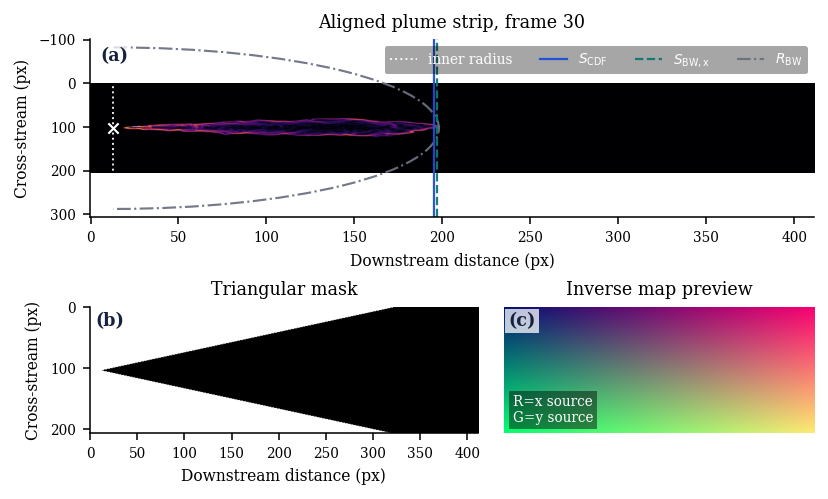

In [98]:
fig = plt.figure(figsize=(5.8, 3.45), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1.2, 0.85], width_ratios=[1.25, 1.0])
ax_strip = fig.add_subplot(gs[0, :])
ax_mask = fig.add_subplot(gs[1, 0])
ax_map = fig.add_subplot(gs[1, 1])

im_strip = ax_strip.imshow(fig_rotation_data["rotated_strip"], cmap="inferno", aspect="auto", origin="upper", vmin=0, vmax=1)
ax_strip.set_title(f"Aligned plume strip, frame {fig_rotation_data['frame_idx']}")
ax_strip.set_xlabel("Downstream distance (px)")
ax_strip.set_ylabel("Cross-stream (px)")
ax_strip.scatter(
    fig_rotation_data["inner_radius"],
    fig_rotation_data["strip_mid_y"],
    marker="x",
    s=28,
    linewidths=1.1,
    color="white",
    zorder=5,
)
ax_strip.axvline(fig_rotation_data["inner_radius"], color="white", ls=":", lw=1.0, alpha=0.92, label="inner radius")
for value, plot_x, color, label, style in [
    (fig_rotation_data["penetration_cdf"], fig_rotation_data["penetration_cdf_plot_x"], COLORS["blue"], r"$S_{\mathrm{CDF}}$", "-"),
    (fig_rotation_data["penetration_bw_x"], fig_rotation_data["penetration_bw_x_plot_x"], COLORS["accent"], r"$S_{\mathrm{BW,x}}$", "--"),
]:
    if np.isfinite(value):
        ax_strip.axvline(plot_x, color=color, ls=style, lw=1.15, alpha=0.95, label=label)
if np.isfinite(fig_rotation_data["penetration_bw_polar"]):
    polar_arc = Arc(
        (fig_rotation_data["inner_radius"], fig_rotation_data["strip_mid_y"]),
        width=2.0 * fig_rotation_data["penetration_bw_polar"],
        height=2.0 * fig_rotation_data["penetration_bw_polar"],
        theta1=-90.0,
        theta2=90.0,
        color=COLORS["gray"],
        linestyle="-.",
        linewidth=1.1,
        alpha=0.95,
    )
    ax_strip.add_patch(polar_arc)
    ax_strip.plot([], [], color=COLORS["gray"], ls="-.", lw=1.1, label=r"$R_{\mathrm{BW}}$")
legend = ax_strip.legend(frameon=True, loc="upper right", fontsize=7, ncol=4, facecolor="black", edgecolor="none", framealpha=0.35)
for text in legend.get_texts():
    text.set_color("white")

ax_mask.imshow(fig_rotation_data["plume_mask"], cmap="gray_r", aspect="auto", origin="upper")
ax_mask.set_title("Triangular mask")
ax_mask.set_xlabel("Downstream distance (px)")
ax_mask.set_ylabel("Cross-stream (px)")

mapx_scaled = robust_scale_local(fig_rotation_data["mapx"], q_min=0, q_max=100)
mapy_scaled = robust_scale_local(fig_rotation_data["mapy"], q_min=0, q_max=100)
map_preview = np.dstack([mapx_scaled, mapy_scaled, 0.45 * np.ones_like(mapx_scaled)])
ax_map.imshow(map_preview, aspect="auto", origin="upper")
ax_map.set_title("Inverse map preview")
ax_map.set_axis_off()
ax_map.text(
    0.03,
    0.06,
    "R=x source\nG=y source",
    transform=ax_map.transAxes,
    ha="left",
    va="bottom",
    fontsize=7,
    color="white",
    bbox={"facecolor": "black", "edgecolor": "none", "alpha": 0.45, "pad": 2},
)

add_panel_labels([ax_strip, ax_mask, ax_map], labels=["a", "b", "c"], x=0.015, y=0.96)
plt.show()


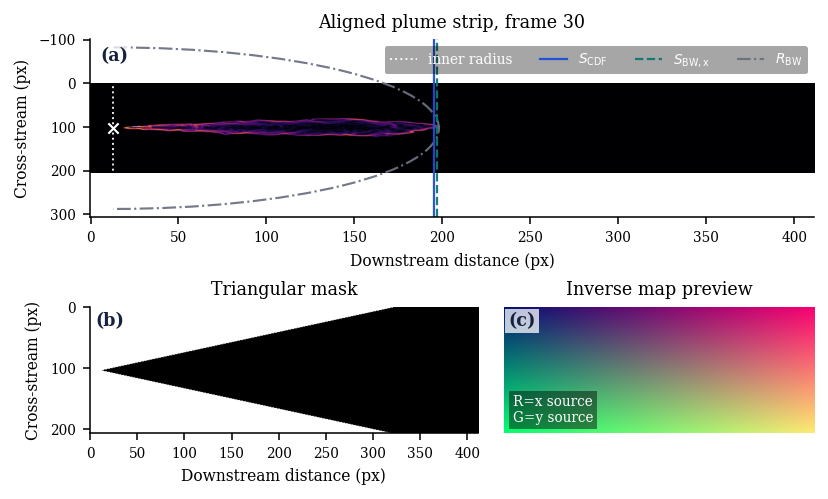

Saved C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\fig_efficient_rotation.png, C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\fig_efficient_rotation.pdf


In [99]:
export_figure(fig, FIG_ROTATION_PARAMS["filename"])
plt.close(fig)


### fig_mie_metrics_summary


In [100]:
FIG_METRICS_PARAMS = {
    "filename": "fig_mie_metrics_summary.png",
    "plume_idx": 0,
}
FIG_METRICS_PARAMS


{'filename': 'fig_mie_metrics_summary.png', 'plume_idx': 0}

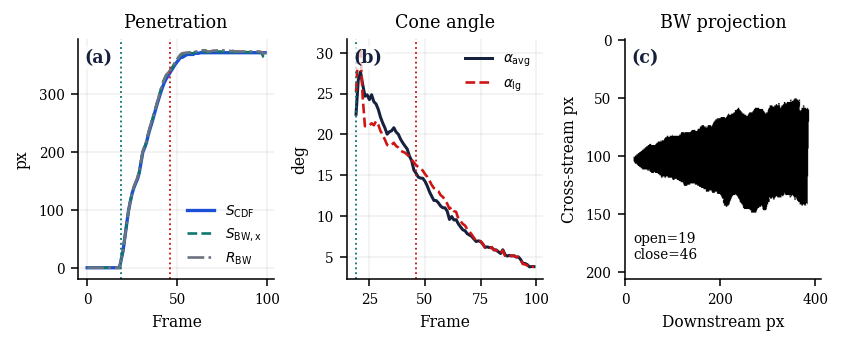

In [101]:
plume_idx = FIG_METRICS_PARAMS["plume_idx"]
metric_data = {
    "penetration_cdf": metrics_df[f"penetration_cdf_plume_{plume_idx}"].to_numpy(),
    "penetration_bw_x": metrics_df[f"penetration_bw_x_plume_{plume_idx}"].to_numpy(),
    "penetration_bw_polar": metrics_df[f"penetration_bw_polar_plume_{plume_idx}"].to_numpy(),
    "area": metrics_df[f"area_plume_{plume_idx}"].to_numpy(),
    "estimated_volume": metrics_df[f"estimated_volume_plume_{plume_idx}"].to_numpy(),
    "cone_angle_average": metrics_df[f"cone_angle_average_plume_{plume_idx}"].to_numpy(),
    "cone_angle_linear_regression": metrics_df[f"cone_angle_linear_regression_plume_{plume_idx}"].to_numpy(),
    "nozzle_opening": float(metrics_df[f"nozzle_opening_plume_{plume_idx}"].iloc[0]),
    "nozzle_closing": float(metrics_df[f"nozzle_closing_plume_{plume_idx}"].iloc[0]),
}
frame_idx = metrics_df["frame_idx"].to_numpy()

fig, axs = plt.subplots(1, 3, figsize=(5.9, 2.35), constrained_layout=True)
axs[0].plot(frame_idx, metric_data["penetration_cdf"], color=COLORS["blue"], lw=1.7, label=r"$S_{\mathrm{CDF}}$")
axs[0].plot(frame_idx, metric_data["penetration_bw_x"], color=COLORS["accent"], lw=1.35, ls="--", label=r"$S_{\mathrm{BW,x}}$")
axs[0].plot(frame_idx, metric_data["penetration_bw_polar"], color=COLORS["gray"], lw=1.35, ls="-.", label=r"$R_{\mathrm{BW}}$")
axs[0].set_title("Penetration")
axs[0].set_xlabel("Frame")
axs[0].set_ylabel("px")
axs[0].legend(frameon=False, fontsize=7)
axs[0].grid(True, alpha=0.18)

axs[1].plot(frame_idx, metric_data["cone_angle_average"], color=COLORS["ink"], lw=1.55, label=r"$\alpha_{\mathrm{avg}}$")
axs[1].plot(frame_idx, metric_data["cone_angle_linear_regression"], color=COLORS["red"], lw=1.35, ls="--", label=r"$\alpha_{\mathrm{lg}}$")
axs[1].set_title("Cone angle")
axs[1].set_xlabel("Frame")
axs[1].set_ylabel("deg")
axs[1].legend(frameon=False, fontsize=7)
axs[1].grid(True, alpha=0.18)

axs[2].imshow(hp_segments_bw_np[plume_idx].max(axis=0), cmap="gray_r", aspect="auto", origin="upper")
axs[2].set_title("BW projection")
axs[2].set_xlabel("Downstream px")
axs[2].set_ylabel("Cross-stream px")
for marker, color in [
    (metric_data["nozzle_opening"], COLORS["accent"]),
    (metric_data["nozzle_closing"], COLORS["red"]),
]:
    if np.isfinite(marker):
        for ax in axs[:2]:
            ax.axvline(marker, color=color, ls=":", lw=0.95)
axs[2].text(
    0.04,
    0.07,
    f"open={metric_data['nozzle_opening']:.0f}\nclose={metric_data['nozzle_closing']:.0f}",
    transform=axs[2].transAxes,
    ha="left",
    va="bottom",
    fontsize=7,
    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.78, "pad": 2},
)
add_panel_labels(axs, labels=["a", "b", "c"], x=0.03, y=0.96)


In [102]:
metric_data

{'penetration_cdf': array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  15.,  30.,  53.,
         76.,  98., 114., 128., 138., 146., 153., 164., 182., 200., 207.,
        216., 229., 240., 250., 261., 272., 283., 293., 303., 312., 320.,
        326., 331., 336., 341., 346., 351., 355., 359., 363., 363., 365.,
        367., 368., 368., 368., 368., 370., 370., 370., 371., 371., 371.,
        371., 371., 371., 371., 371., 371., 371., 371., 371., 371., 371.,
        371., 371., 371., 371., 371., 371., 371., 371., 371., 371., 371.,
        371., 371., 371., 371., 371., 371., 371., 371., 371., 371., 371.,
        371.]),
 'penetration_bw_x': array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  15.,  30.,  53.,
         76.,  98., 115., 128., 139., 147., 154., 166., 184., 202., 209.,
        217., 232., 243., 253., 264., 275., 286., 297., 3

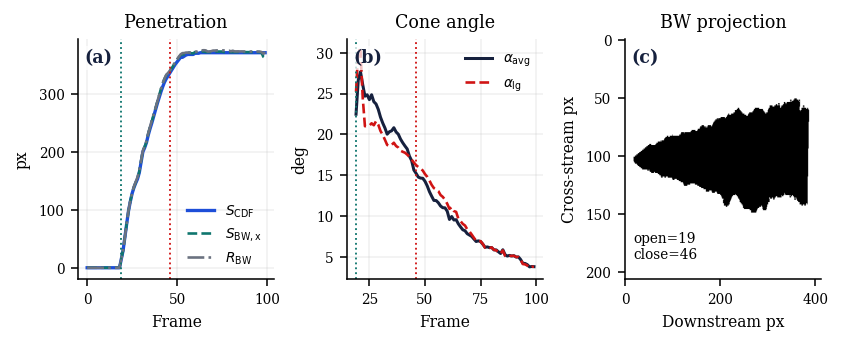

Saved C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\fig_mie_metrics_summary.png, C:\Users\Jiang\Documents\Mie_Postprocessing_Py\images\fig_mie_metrics_summary.pdf


In [103]:
export_figure(fig, FIG_METRICS_PARAMS["filename"])
plt.close(fig)


### debug_video_exports_and_playback

Save processed videos and rotated plume segments to AVI. Playback is optional and controlled by flags.


In [104]:
VIDEO_DEBUG_PARAMS = {
    "prefix": "thesis_publication_figures",
    "save_videos": False,
    "play_processed": False,
    "play_segments": False,
    "gain": 1.0,
    "intv": 17,
}

if VIDEO_DEBUG_PARAMS["save_videos"]:
    print("AVI export is intentionally left to mie_multi_hole.py; this notebook keeps the figure workflow linear.")

if repo_playback is not None and hasattr(repo_playback, "play_videos_side_by_side"):
    if VIDEO_DEBUG_PARAMS["play_processed"]:
        repo_playback.play_videos_side_by_side(
            [foreground_np, highpass_np],
            gain=VIDEO_DEBUG_PARAMS["gain"],
            intv=VIDEO_DEBUG_PARAMS["intv"],
        )
    if VIDEO_DEBUG_PARAMS["play_segments"]:
        repo_playback.play_videos_side_by_side(
            np.swapaxes(255.0 * hp_segments_bw_np, 2, 3).tolist(),
            gain=VIDEO_DEBUG_PARAMS["gain"],
            intv=VIDEO_DEBUG_PARAMS["intv"],
        )
else:
    print("Playback helper is unavailable in this kernel.")
